In [39]:
from pathlib import Path
from typing import Dict, Any, List
import pandas as pd
import seaborn as sns
from music21 import converter, instrument, meter, key, tempo, note, chord, stream, interval, harmony, voiceLeading
import re
import string
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def load_mxl_corpus(data_root: str = "data") -> Dict[str, pd.DataFrame]:
    """
    Read all .mxl scores recursively from data_root and return corpus tables.

    Returns:
        {
            "scores": score-level metadata and global stats (1 row per score),
            "parts": part-level stats (1 row per part),
            "events": note/chord/rest-level events (1 row per event),
            "errors": files that failed to parse
        }
    """
    root = Path(data_root)
    if not root.exists():
        raise FileNotFoundError(f"Path does not exist: {root.resolve()}")

    # Case-insensitive .mxl search
    mxl_files = [p for p in root.rglob("*") if p.is_file() and p.suffix.lower() == ".mxl"]

    score_rows: List[Dict[str, Any]] = []
    part_rows: List[Dict[str, Any]] = []
    event_rows: List[Dict[str, Any]] = []
    error_rows: List[Dict[str, Any]] = []

    for fp in mxl_files:
        rel_path = str(fp.relative_to(root))
        path_parts = fp.parts

        # Try to infer collection/book from folder names
        collection = path_parts[-3] if len(path_parts) >= 3 else None
        book = path_parts[-2] if len(path_parts) >= 2 else None

        try:
            sc = converter.parse(str(fp))
        except Exception as exc:
            error_rows.append(
                {
                    "file_path": str(fp),
                    "relative_path": rel_path,
                    "error_type": type(exc).__name__,
                    "error_message": str(exc),
                }
            )
            continue

        md = sc.metadata
        title = getattr(md, "title", None) if md else None
        composer = getattr(md, "composer", None) if md else None

        # Global score objects (first seen)
        ts = sc.recurse().getElementsByClass(meter.TimeSignature)
        ks = sc.recurse().getElementsByClass(key.KeySignature)
        mm = sc.recurse().getElementsByClass(tempo.MetronomeMark)

        part_list = list(sc.parts)
        num_parts = len(part_list)

        total_measures = 0
        total_notes = 0
        total_rests = 0
        total_chords = 0
        total_lyrics = 0

        for part_idx, part in enumerate(part_list, start=1):
            part_id = getattr(part, "id", None)
            part_name = getattr(part, "partName", None)

            inst = None
            try:
                inst = part.getInstrument(returnDefault=False)
            except Exception:
                inst = None

            measures = list(part.getElementsByClass(stream.Measure))
            n_measures = len(measures)

            notes_flat = list(part.recurse().getElementsByClass(note.Note))
            rests_flat = list(part.recurse().getElementsByClass(note.Rest))
            chords_flat = list(part.recurse().getElementsByClass(chord.Chord))

            n_notes = len(notes_flat)
            n_rests = len(rests_flat)
            n_chords = len(chords_flat)

            # Lyrics can be None or list-like depending on encoding
            lyric_count = 0
            for n in notes_flat:
                if getattr(n, "lyrics", None):
                    lyric_count += len([ly for ly in n.lyrics if getattr(ly, "text", None)])
                elif getattr(n, "lyric", None):
                    lyric_count += 1

            total_measures = max(total_measures, n_measures)
            total_notes += n_notes
            total_rests += n_rests
            total_chords += n_chords
            total_lyrics += lyric_count

            part_rows.append(
                {
                    "file_path": str(fp),
                    "relative_path": rel_path,
                    "collection": collection,
                    "book_folder": book,
                    "part_index": part_idx,
                    "part_id": part_id,
                    "part_name": part_name,
                    "instrument_name": getattr(inst, "instrumentName", None) if inst else None,
                    "instrument_family": getattr(inst, "instrumentFamily", None) if inst else None,
                    "n_measures": n_measures,
                    "n_notes": n_notes,
                    "n_rests": n_rests,
                    "n_chords": n_chords,
                    "n_lyrics_tokens": lyric_count,
                }
            )

            # Event-level extraction for later statistical analysis
            for el in part.recurse().notesAndRests:
                row = {
                    "file_path": str(fp),
                    "relative_path": rel_path,
                    "collection": collection,
                    "book_folder": book,
                    "part_index": part_idx,
                    "offset": float(el.offset) if el.offset is not None else None,
                    "quarter_length": float(el.quarterLength) if el.quarterLength is not None else None,
                    "measure_number": getattr(el, "measureNumber", None),
                    "is_grace": bool(getattr(el, "duration", None) and el.duration.isGrace),
                }

                if isinstance(el, note.Note):
                    row.update(
                        {
                            "event_type": "note",
                            "pitch_name": el.pitch.nameWithOctave if el.pitch else None,
                            "midi": int(el.pitch.midi) if el.pitch else None,
                            "is_rest": False,
                            "is_chord": False,
                            "lyric": getattr(el, "lyric", None),
                        }
                    )
                elif isinstance(el, chord.Chord):
                    row.update(
                        {
                            "event_type": "chord",
                            "pitch_name": ".".join(p.nameWithOctave for p in el.pitches),
                            "midi": ".".join(str(int(p.midi)) for p in el.pitches),
                            "is_rest": False,
                            "is_chord": True,
                            "lyric": None,
                        }
                    )
                else:  # Rest
                    row.update(
                        {
                            "event_type": "rest",
                            "pitch_name": None,
                            "midi": None,
                            "is_rest": True,
                            "is_chord": False,
                            "lyric": None,
                        }
                    )

                event_rows.append(row)

        score_rows.append(
            {
                "file_path": str(fp),
                "relative_path": rel_path,
                "collection": collection,
                "book_folder": book,
                "filename": fp.name,
                "title": title,
                "composer": composer,
                "n_parts": num_parts,
                "n_measures_max_part": total_measures,
                "n_notes_total": total_notes,
                "n_rests_total": total_rests,
                "n_chords_total": total_chords,
                "n_lyrics_tokens_total": total_lyrics,
                "time_signature_first": ts[0].ratioString if len(ts) else None,
                "key_signature_sharps_first": ks[0].sharps if len(ks) else None,
                "tempo_first_bpm": mm[0].number if len(mm) else None,
            }
        )

    return {
        "scores": pd.DataFrame(score_rows),
        "parts": pd.DataFrame(part_rows),
        "events": pd.DataFrame(event_rows),
        "errors": pd.DataFrame(error_rows),
    }

tables = load_mxl_corpus("data")
scores_df = tables["scores"]
parts_df = tables["parts"]
events_df = tables["events"]
errors_df = tables["errors"]

scores_df.head(), parts_df.head(), events_df.head(), errors_df.head()

c:\UPF\Monteverdi_sprezzatura\Monteverdi-s-Sprezzatura-Analysis\.venv\Lib\site-packages\music21\musicxml\xmlToM21.py:1995: MusicXMLWarning: The following exception took place in m. 1 in part Basso da  Coro  gamba.
  warnings.warn(


(                                           file_path  \
 0        data\Caccini\Caccini-Amarilli_mia_bella.mxl   
 1  data\choral_wiki_monteverdi_cleaned\Book_1\1-0...   
 2  data\choral_wiki_monteverdi_cleaned\Book_1\1-0...   
 3  data\choral_wiki_monteverdi_cleaned\Book_1\1-0...   
 4  data\choral_wiki_monteverdi_cleaned\Book_1\1-0...   
 
                                        relative_path collection  \
 0             Caccini\Caccini-Amarilli_mia_bella.mxl       data   
 1  choral_wiki_monteverdi_cleaned\Book_1\1-01-Ch'...     Book_1   
 2  choral_wiki_monteverdi_cleaned\Book_1\1-02-Se ...     Book_1   
 3  choral_wiki_monteverdi_cleaned\Book_1\1-03-A c...     Book_1   
 4  choral_wiki_monteverdi_cleaned\Book_1\1-04-Amo...     Book_1   
 
                                          book_folder  \
 0                                            Caccini   
 1                            1-01-Ch'ami la mia vita   
 2                           1-02-Se per havervi oime   
 3  1-03-A che tor

C:\Users\User\AppData\Local\Temp\ipykernel_20220\2504066312.py:81: StreamIteratorInefficientWarning: getElementAtOrBefore is not defined on StreamIterators. Call .stream() first for efficiency
  sounding_other = other_part_notes.getElementAtOrBefore(t_curr, [note.Note])
c:\UPF\Monteverdi_sprezzatura\Monteverdi-s-Sprezzatura-Analysis\.venv\Lib\site-packages\music21\musicxml\xmlToM21.py:1995: MusicXMLWarning: The following exception took place in m. 1 in part Basso da  Coro  gamba.
  warnings.warn(


,book,n_scores,n_dissonances,n_unprepared_or_unresolved,ratio_unprepared_unresolved
0,1,21,5345,2486,0.465108
1,2,20,3538,801,0.226399
2,3,20,7972,2650,0.332413
3,4,20,4144,1301,0.313948
4,5,20,7730,2782,0.359897
5,6,15,4728,1559,0.329738
6,7,28,9821,3623,0.368903
7,8,23,23370,8429,0.360676
8,9,16,5574,1759,0.315572


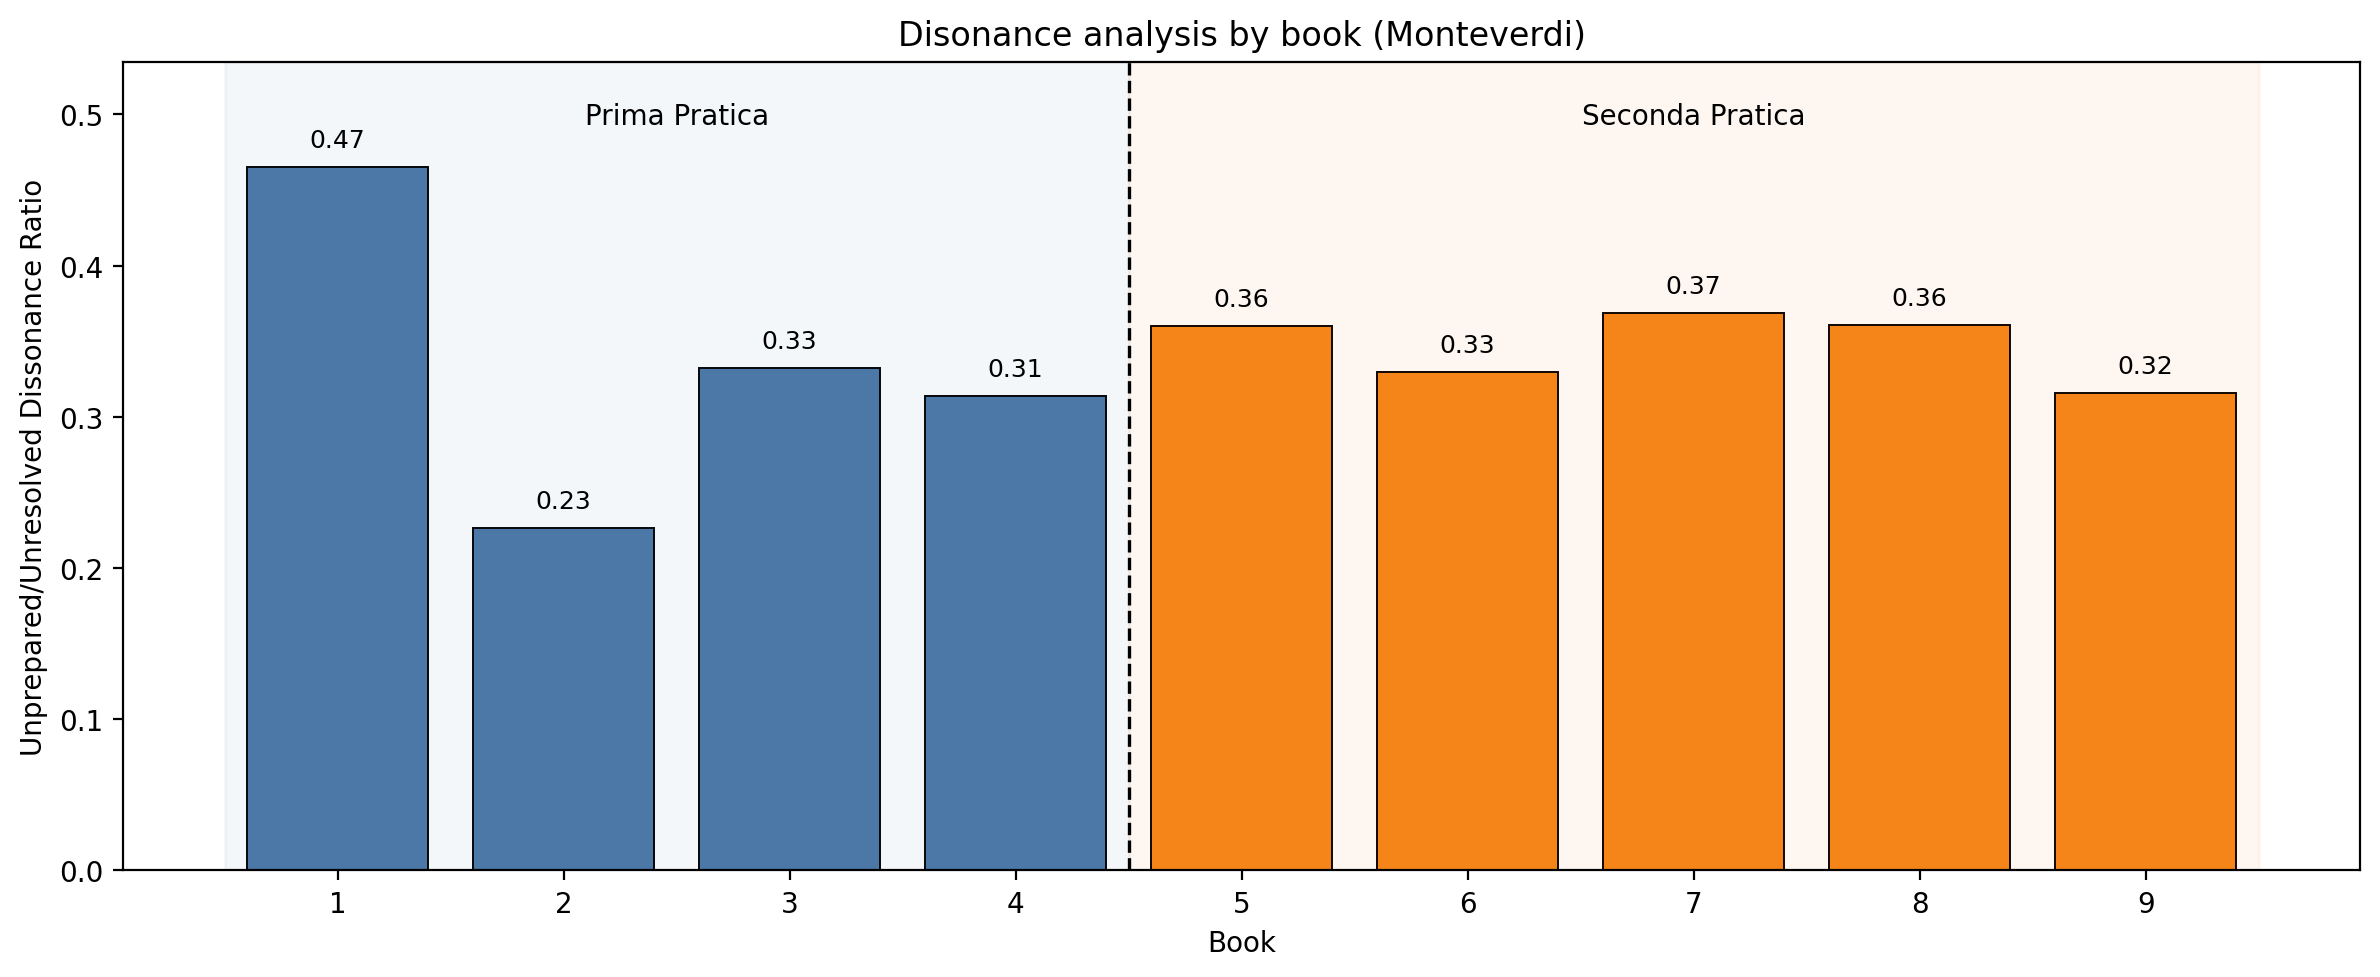

In [6]:
# Dissonant interval classes vs bass (mod 12):
# m2/M2 (1,2), tritone (6), m7/M7 (10,11)
DISSONANT_MOD12 = {1, 2, 6, 10, 11}

def _book_from_path(path_str: str):
    m = re.search(r"Book_(\d+)", path_str.replace("\\", "/"), flags=re.IGNORECASE)
    return int(m.group(1)) if m else None

def _is_step(pitch1, pitch2):
    if pitch1 is None or pitch2 is None: return False
    return abs(pitch2.midi - pitch1.midi) <= 2


def disonance_analysis_advanced(data_root="data", only_books=True):
    """
    Cuantifica disonancias 'problemáticas' (Seconda Pratica) evaluando TODAS las voces.
    Una disonancia es problemática si:
    - No está preparada: no proviene de una nota mantenida (suspensión/ligadura) 
      ni se llegó a ella por grado conjunto.
    - No resuelve: la voz no se mueve por grado conjunto inmediatamente después.
    """
    root = Path(data_root)
    mxl_files = [p for p in root.rglob("*") if p.is_file() and p.suffix.lower() == ".mxl"]
    rows = []

    for fp in mxl_files:
        rel = str(fp.relative_to(root))
        book_num = _book_from_path(rel)

        if only_books and (book_num is None or not (1 <= book_num <= 9)):
            continue

        try:
            sc = converter.parse(str(fp))
        except Exception as exc:
            continue # Omitimos el manejo de errores largo para simplificar visualmente

        parts = list(sc.parts)
        if len(parts) < 2: continue

        # Aplanamos todas las partes para un acceso rápido
        parts_flat = [p.flatten().notes for p in parts]
        
        total_diss = 0
        total_problematic = 0

        # Iteramos sobre cada parte (voz) para evaluar cada una de sus notas
        for part_idx, part_notes in enumerate(parts_flat):
            notes_list = [n for n in part_notes if isinstance(n, note.Note)]
            
            for j in range(1, len(notes_list) - 1):
                prev_n = notes_list[j - 1]
                curr_n = notes_list[j]
                next_n = notes_list[j + 1]
                
                t_curr = float(curr_n.offset)
                
                # 1. ¿Es disonante contra CUALQUIER otra voz que esté sonando ahora?
                is_diss = False
                for other_part_idx, other_part_notes in enumerate(parts_flat):
                    if part_idx == other_part_idx: continue
                    
                    # Obtenemos la nota de la otra voz que suena en el mismo instante
                    sounding_other = other_part_notes.getElementAtOrBefore(t_curr, [note.Note])
                    if sounding_other and sounding_other.offset <= t_curr < (sounding_other.offset + sounding_other.quarterLength):
                        # Medimos la disonancia contra esta voz
                        semitones = abs(curr_n.pitch.midi - sounding_other.pitch.midi) % 12
                        if semitones in DISSONANT_MOD12:
                            is_diss = True
                            break # Con que choque con una voz, ya es una nota disonante
                
                if not is_diss:
                    continue

                total_diss += 1

                # 2. EVALUACIÓN DE PREPARACIÓN (Aquí entra tu idea del "Buffer")
                # ¿Era la nota anterior exactamente el mismo pitch? (Ligadura / Suspensión)
                is_held_over = (prev_n.pitch.midi == curr_n.pitch.midi)
                
                # ¿Se llegó a ella por paso? (Grado conjunto)
                entered_by_step = _is_step(prev_n.pitch, curr_n.pitch)
                
                prepared = is_held_over or entered_by_step

                # 3. EVALUACIÓN DE RESOLUCIÓN
                # ¿Sale por paso hacia la siguiente nota?
                resolved = _is_step(curr_n.pitch, next_n.pitch)

                # Si falla la preparación O falla la resolución, es Seconda Pratica pura
                if (not prepared) or (not resolved):
                    total_problematic += 1

        ratio = (total_problematic / total_diss) if total_diss > 0 else np.nan

        rows.append({
            "file_path": str(fp),
            "book": book_num,
            "n_dissonances": total_diss,
            "n_unprepared_or_unresolved": total_problematic,
            "ratio_unprepared_unresolved": ratio
        })

    # (El resto del código de agregación con Pandas sigue siendo exactamente el mismo)
    score_df = pd.DataFrame(rows)
    valid = score_df.dropna(subset=["book"]).copy()
    valid = valid[valid["book"].between(1, 9)]

    agg = valid.groupby("book", as_index=False).agg(
        n_scores=("file_path", "count"),
        n_dissonances=("n_dissonances", "sum"),
        n_unprepared_or_unresolved=("n_unprepared_or_unresolved", "sum"),
    )
    agg["ratio_unprepared_unresolved"] = np.where(
        agg["n_dissonances"] > 0,
        agg["n_unprepared_or_unresolved"] / agg["n_dissonances"],
        np.nan
    )
    return score_df, agg

def plot_disonance_by_book(book_df, value_col="ratio_unprepared_unresolved"):
    """
    Bar chart by book with visual separation:
    Books 1-4 = Prima Pratica, Books 5-9 = Seconda Pratica.
    """
    plot_df = book_df.sort_values("book").copy()

    # Ensure all books appear even if missing
    full_books = pd.DataFrame({"book": list(range(1, 10))})
    plot_df = full_books.merge(plot_df, on="book", how="left")
    plot_df["practice"] = np.where(plot_df["book"] <= 4, "Prima Pratica", "Seconda Pratica")

    colors = plot_df["practice"].map({
        "Prima Pratica": "#4C78A8",
        "Seconda Pratica": "#F58518"
    }).fillna("#B0B0B0")

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(plot_df["book"], plot_df[value_col], color=colors, edgecolor="black", linewidth=0.7)

    # Visual split between 4 and 5
    ax.axvline(4.5, color="black", linestyle="--", linewidth=1.2)
    ax.axvspan(0.5, 4.5, alpha=0.06, color="#4C78A8")
    ax.axvspan(4.5, 9.5, alpha=0.06, color="#F58518")

    ax.set_xticks(range(1, 10))
    ax.set_xlabel("Book")
    ax.set_ylabel("Unprepared/Unresolved Dissonance Ratio")
    ax.set_title("Disonance analysis by book (Monteverdi)")
    ax.set_ylim(0, min(1.0, np.nanmax(plot_df[value_col].values) * 1.15 if np.isfinite(np.nanmax(plot_df[value_col].values)) else 1.0))

    # Small labels
    for x, y in zip(plot_df["book"], plot_df[value_col]):
        if pd.notna(y):
            ax.text(x, y + 0.01, f"{y:.2f}", ha="center", va="bottom", fontsize=9)

    # Practice labels
    ax.text(2.5, ax.get_ylim()[1] * 0.95, "Prima Pratica", ha="center", va="top", fontsize=10)
    ax.text(7.0, ax.get_ylim()[1] * 0.95, "Seconda Pratica", ha="center", va="top", fontsize=10)

    plt.tight_layout()
    plt.show()

score_diss_df, book_diss_df = disonance_analysis_advanced(data_root="data", only_books=True)
display(book_diss_df)
plot_disonance_by_book(book_diss_df)

In [ ]:
# BASS_LABEL==========================================
# 5. Descubrimiento de etiquetas de Bajo / Basso Continuo desde parts_df
# ==========================================
BASS_LABEL_TOKENS = {
    "basso",
    "bass",
    "bajo",
    "continuo",
    "basso continuo",
    "bassus",
}


def normalize_part_label(text):
    """Normaliza etiquetas de partes para detectar variantes de bajo/continuo."""
    if pd.isna(text):
        return None

    text = str(text).strip().lower()
    if not text:
        return None

    text = text.replace("&", " and ")
    text = re.sub(r"\bb\s*\.?\s*c\s*\.?\b", " basso continuo ", text)
    text = re.sub(r"\bbasso\s+cont\.?\b", " basso continuo ", text)
    text = re.sub(r"[^a-z0-9]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    replacements = {
        "continuo organo": "basso continuo organo",
        "continuo cembalo": "basso continuo cembalo",
        "basso cont": "basso continuo",
    }
    return replacements.get(text, text)



def is_bass_or_continuo_label(text):
    """Devuelve True si la etiqueta parece identificar una parte de bajo o bajo continuo."""
    normalized = normalize_part_label(text)
    if not normalized:
        return False

    if normalized in BASS_LABEL_TOKENS:
        return True

    if "basso continuo" in normalized:
        return True

    tokens = set(normalized.split())
    return bool(tokens & BASS_LABEL_TOKENS)



def build_bass_label_candidates(parts_df):
    """Construye una tabla larga con etiquetas candidatas extraídas de parts_df."""
    candidate_fields = [
        column
        for column in ["part_name", "part_id", "instrument_name"]
        if column in parts_df.columns
    ]

    candidate_rows = []
    for row in parts_df.itertuples(index=False):
        row_dict = row._asdict()
        book_value = row_dict.get("book_folder")
        book_num = _extract_book_num(row_dict.get("relative_path"), book_value)

        for source_field in candidate_fields:
            raw_label = row_dict.get(source_field)
            normalized_label = normalize_part_label(raw_label)
            if not normalized_label:
                continue

            candidate_rows.append(
                {
                    "relative_path": row_dict.get("relative_path"),
                    "book": book_num,
                    "part_index": row_dict.get("part_index"),
                    "source_field": source_field,
                    "raw_label": str(raw_label),
                    "normalized_label": normalized_label,
                    "is_bass_candidate": is_bass_or_continuo_label(raw_label),
                }
            )

    return pd.DataFrame(candidate_rows)



def summarize_bass_labels(parts_df):
    """Resume variantes de etiquetas de bajo/continuo y devuelve artefactos reutilizables."""
    candidates_df = build_bass_label_candidates(parts_df)
    if candidates_df.empty:
        empty = pd.DataFrame()
        return {
            "candidates": empty,
            "summary": empty,
            "matched_parts": empty,
            "counts_by_book": empty,
            "normalized_labels": set(),
        }

    bass_candidates_df = candidates_df[candidates_df["is_bass_candidate"]].copy()

    summary_df = (
        bass_candidates_df.groupby(["normalized_label", "raw_label"], as_index=False)
        .agg(
            n_parts=("part_index", "count"),
            n_scores=("relative_path", "nunique"),
            source_fields=("source_field", lambda s: ", ".join(sorted(set(s)))),
            example_file=("relative_path", "first"),
        )
        .sort_values(["normalized_label", "n_parts"], ascending=[True, False])
        .reset_index(drop=True)
    )

    matched_parts_df = (
        bass_candidates_df[["relative_path", "book", "part_index", "raw_label", "normalized_label"]]
        .drop_duplicates()
        .sort_values(["book", "relative_path", "part_index", "normalized_label"])
        .reset_index(drop=True)
    )

    counts_by_book_df = (
        matched_parts_df.groupby("book", as_index=False)
        .agg(
            n_scores_with_bass_label=("relative_path", "nunique"),
            n_parts_matched=("part_index", "count"),
        )
        .sort_values("book")
        .reset_index(drop=True)
    )
    counts_by_book_df["practice"] = np.where(
        counts_by_book_df["book"] <= 4,
        "Prima Pratica",
        "Seconda Pratica",
    )

    normalized_labels = set(summary_df["normalized_label"].unique())

    return {
        "candidates": candidates_df,
        "summary": summary_df,
        "matched_parts": matched_parts_df,
        "counts_by_book": counts_by_book_df,
        "normalized_labels": normalized_labels,
    }



def part_is_bass_or_continuo(part_row, accepted_labels=None):
    """Helper reutilizable para evaluar filas de parts_df en análisis posteriores."""
    accepted_labels = accepted_labels or discovered_bass_labels

    for field in ("part_name", "part_id", "instrument_name"):
        if field not in part_row.index:
            continue
        normalized = normalize_part_label(part_row[field])
        if normalized and normalized in accepted_labels:
            return True

    return False


bass_label_results = summarize_bass_labels(parts_df)
bass_label_candidates_df = bass_label_results["candidates"]
bass_label_summary_df = bass_label_results["summary"]
bass_parts_lookup_df = bass_label_results["matched_parts"]
bass_counts_by_book_df = bass_label_results["counts_by_book"]
discovered_bass_labels = bass_label_results["normalized_labels"]

print("Normalized bass/continuo labels discovered:")
print(sorted(discovered_bass_labels))
print()
print("Counts by book:")
display(bass_counts_by_book_df)
print("Label summary:")
display(bass_label_summary_df)
print("Matched part examples:")
display(bass_parts_lookup_df.head(20))

Normalized bass/continuo labels discovered:
['3 basso', '3 basso 2', '3 basso a b', '3 basso a c 2', '3 basso continuo', '3 basso continuo 1', '3 basso continuo 2', '3 basso g b', '3 basso g c 1', '3 basso g d', '3 basso i e d', 'bass', 'bass 2', 'bass e c 3', 'basso', 'basso a e', 'basso b d', 'basso b d 3 2', 'basso b e', 'basso continuo', 'basso continuo 1', 'basso continuo 2', 'basso d d', 'basso d e', 'basso e b', 'basso e c', 'basso e d', 'basso f a', 'basso f b', 'basso f c', 'basso f d', 'basso f g', 'basso g b', 'basso g c', 'basso g d', 'basso ii f d', 'double bass']

Counts by book:


,book,n_scores_with_bass_label,n_parts_matched,practice
0,1.0,21,21,Prima Pratica
1,2.0,20,20,Prima Pratica
2,3.0,20,20,Prima Pratica
3,4.0,18,19,Prima Pratica
4,5.0,20,27,Seconda Pratica
5,6.0,15,23,Seconda Pratica
6,7.0,28,38,Seconda Pratica
7,8.0,23,38,Seconda Pratica
8,9.0,16,27,Seconda Pratica


Label summary:


,normalized_label,raw_label,n_parts,n_scores,source_fields,example_file
0,3 basso,3 Basso,2,1,"part_id, part_name",choral_wiki_monteverdi_cleaned\Book_6\6-05-Zef...
1,3 basso 2,3 Basso 2,4,1,"part_id, part_name",choral_wiki_monteverdi_cleaned\Book_5\5-19-Que...
2,3 basso a b,3 Basso A – b,2,1,"part_id, part_name",choral_wiki_monteverdi_cleaned\Book_8\8-18-Lam...
3,3 basso a c 2,3 Basso A – c' 2,2,1,"part_id, part_name",choral_wiki_monteverdi_cleaned\Book_9\9-10-Non...
4,3 basso continuo,3 B. c.,6,3,"part_id, part_name",choral_wiki_monteverdi_cleaned\Book_8\8-05-Arm...
5,3 basso continuo,3 B. c.,2,1,"part_id, part_name",choral_wiki_monteverdi_cleaned\Book_6\6-05-Zef...
6,3 basso continuo 1,3 B. c. 1,2,1,"part_id, part_name","choral_wiki_monteverdi_cleaned\Book_9\9-15-Su,..."
7,3 basso continuo 2,3 B. c. 2,2,1,"part_id, part_name",choral_wiki_monteverdi_cleaned\Book_5\5-19-Que...
8,3 basso g b,3 Basso G – b,2,1,"part_id, part_name",choral_wiki_monteverdi_cleaned\Book_9\9-12-All...
9,3 basso g c 1,3 Basso G – c' 1,2,1,"part_id, part_name","choral_wiki_monteverdi_cleaned\Book_9\9-15-Su,..."


Matched part examples:


,relative_path,book,part_index,raw_label,normalized_label
0,choral_wiki_monteverdi_cleaned\Book_1\1-01-Ch'...,1.0,5,Basso,basso
1,choral_wiki_monteverdi_cleaned\Book_1\1-02-Se ...,1.0,5,Basso,basso
2,choral_wiki_monteverdi_cleaned\Book_1\1-03-A c...,1.0,5,Basso,basso
3,choral_wiki_monteverdi_cleaned\Book_1\1-04-Amo...,1.0,5,Basso,basso
4,choral_wiki_monteverdi_cleaned\Book_1\1-05-Bac...,1.0,5,Basso,basso
5,choral_wiki_monteverdi_cleaned\Book_1\1-06-Se ...,1.0,5,Basso,basso
6,choral_wiki_monteverdi_cleaned\Book_1\1-07-Fil...,1.0,5,Basso,basso
7,choral_wiki_monteverdi_cleaned\Book_1\1-08-Poi...,1.0,5,Basso,basso
8,choral_wiki_monteverdi_cleaned\Book_1\1-09-Fum...,1.0,5,Basso,basso
9,choral_wiki_monteverdi_cleaned\Book_1\1-10-Alm...,1.0,5,Basso,basso


In [34]:
# ==========================================
# 6. Lista de etiquetas raw de Basso
# ==========================================

def get_raw_basso_labels(candidates_df):
    """Devuelve una lista en minúsculas con etiquetas raw de basso, excluyendo basso continuo."""
    if candidates_df.empty:
        return []

    normalized_labels = candidates_df["normalized_label"].fillna("")
    basso_mask = normalized_labels.str.contains(r"\bbasso\b", case=False, regex=True)
    not_continuo_mask = ~normalized_labels.str.contains(r"\bcontinuo\b", case=False, regex=True)

    raw_labels = (
        candidates_df.loc[basso_mask & not_continuo_mask, "raw_label"]
        .dropna()
        .astype(str)
        .str.strip()
        .str.lower()
    )

    return sorted(raw_labels.unique().tolist())


raw_basso_labels = get_raw_basso_labels(bass_label_candidates_df)
print("Raw lowercase labels for 'basso' only:")
print(raw_basso_labels)

raw_basso_labels_df = pd.DataFrame({
    "raw_basso_label": raw_basso_labels
})
display(raw_basso_labels_df)

Raw lowercase labels for 'basso' only:
['3  basso  a – b', "3  basso  a – c'  2", '3  basso  g – b', "3  basso  g – c'  1", "3  basso  g – d'", "3  basso i  e – d'", '3 basso', '3 basso 2', 'basso', "basso  b – d'", "basso  b – d'  3  2", "basso  d – d'", "basso  d – e'", "basso  e – c '", "basso  e – c'", "basso  e – d'", 'basso  f – a', 'basso  f – b', 'basso  f – g', "basso  f– c'", "basso  g – c'", "basso  g – d'", "basso a – e'", "basso b – e'", "basso d – d'", 'basso e – b', 'basso f – a', 'basso f – b', "basso f – c'", "basso f – d'", 'basso f– b', "basso f– b '", "basso f– d'", 'basso g – b', "basso g – c'", "basso g – d'", "basso ii  f – d'"]


,raw_basso_label
0,3 basso a – b
1,3 basso a – c' 2
2,3 basso g – b
3,3 basso g – c' 1
4,3 basso g – d'
5,3 basso i e – d'
6,3 basso
7,3 basso 2
8,basso
9,basso b – d'


Searching for pieces with Basso Continuo in 184 files...


c:\UPF\Monteverdi_sprezzatura\Monteverdi-s-Sprezzatura-Analysis\.venv\Lib\site-packages\music21\musicxml\xmlToM21.py:1995: MusicXMLWarning: The following exception took place in m. 1 in part Basso da  Coro  gamba.
  warnings.warn(


                                           file_path  book         practice  \
0  data\choral_wiki_monteverdi_cleaned\Book_5\5-1...     5  Seconda Pratica   
1  data\choral_wiki_monteverdi_cleaned\Book_5\5-1...     5  Seconda Pratica   
2  data\choral_wiki_monteverdi_cleaned\Book_5\5-1...     5  Seconda Pratica   
3  data\choral_wiki_monteverdi_cleaned\Book_5\5-1...     5  Seconda Pratica   
4  data\choral_wiki_monteverdi_cleaned\Book_5\5-1...     5  Seconda Pratica   

   Avg_Bass_Duration  Bass_Leap_Ratio  Vocal_Rhythmic_Independence  
0           2.465753         0.702970                     0.502035  
1           1.158929         0.316940                     0.508099  
2           1.799020         0.512048                     0.611360  
3           1.219780         0.495238                     0.397213  
4           1.672222         0.545455                     0.511918  


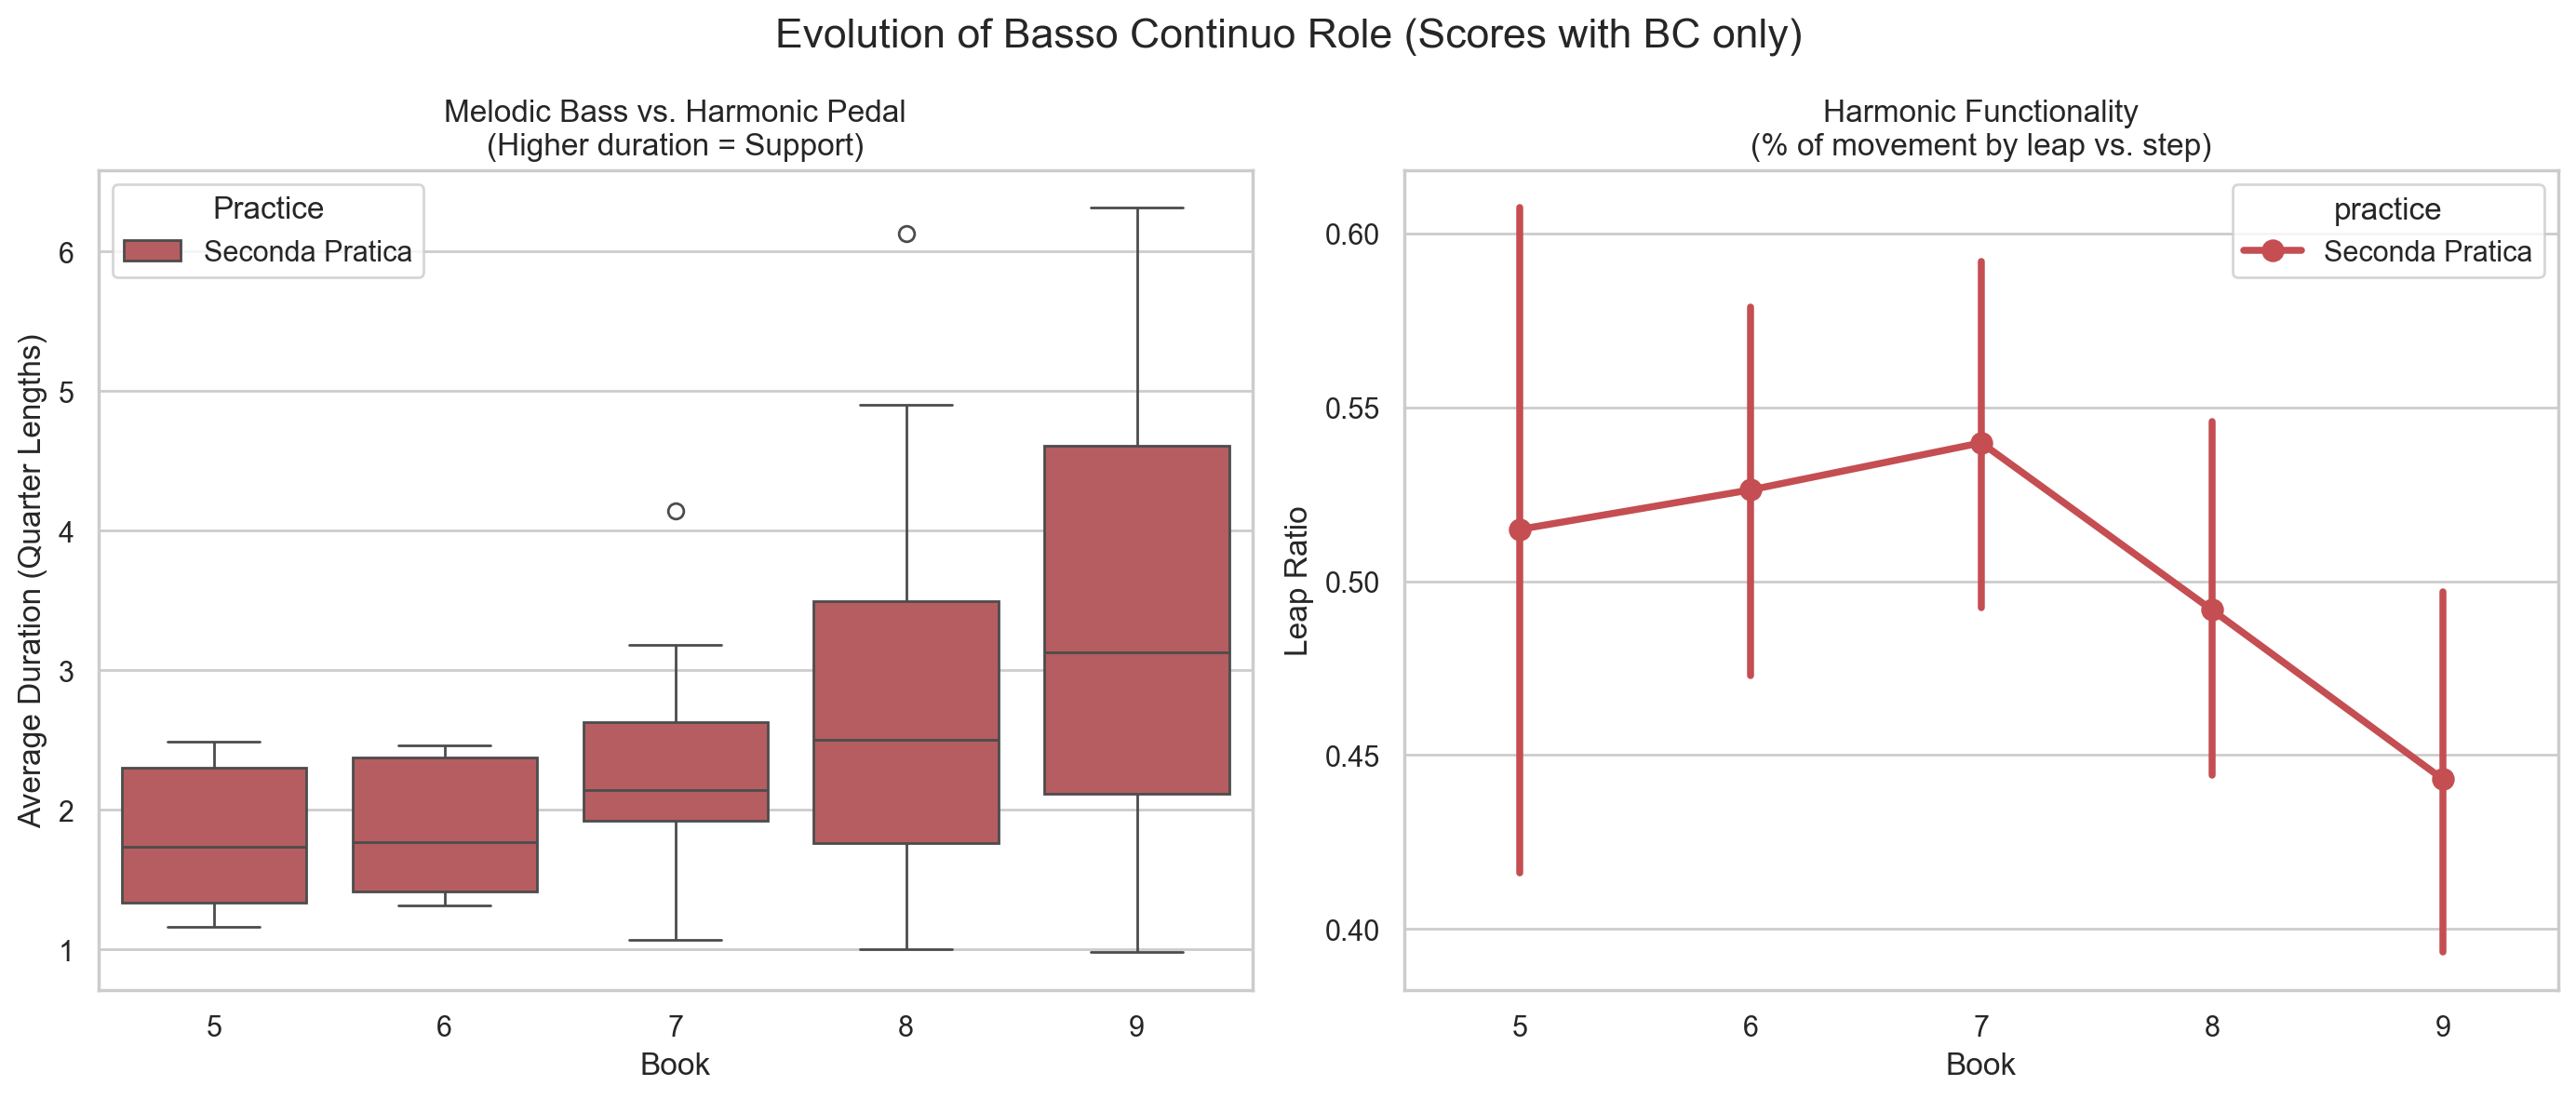

In [29]:
# ==========================================
# 1. Analytical Functions for Texture and Basso Continuo
# ==========================================
def analyze_texture_and_bass(score):
    """
    Analyzes vocal texture (homorhythm vs. polyphony) and the 
    melodic/harmonic behavior of the Basso Continuo.
    Returns None if the piece does NOT have Basso Continuo.
    """
    def is_basso_continuo(part):
        tags = [str(getattr(part, 'partName', '') or ''), str(getattr(part, 'id', '') or '')]
        text = ' '.join(tags).lower()
        
        # Search terms in lowercase
        search_terms = [
            '3  b. c.', '3  b. c.  1', '3 b. c.', '3 b. c. 2', 
            'b c.', 'b. c.', 'b. c.  1', 'b. c.  2', 'bc', 
            'basso continuo', 'continuo', 'basso da coro'
        ]
        return any(k in text for k in search_terms)

    # 1. Separate Bass and Vocal Parts
    basso_parts = [p for p in score.parts if is_basso_continuo(p)]
    if not basso_parts:
        return None # DISCARD pieces without Basso Continuo
        
    basso_part = basso_parts[0]
    vocal_parts = [p for p in score.parts if p is not basso_part]
    
    if not vocal_parts:
        return None

    # 2. Basso Continuo Analysis (Support vs. Melody)
    bass_notes = [n for n in basso_part.flatten().notes if isinstance(n, note.Note)]
    if not bass_notes:
        return None
        
    # a) Average duration (longer notes = harmonic support)
    avg_bass_duration = sum(n.quarterLength for n in bass_notes) / len(bass_notes)
    
    # b) Percentage of leaps (Leaps vs. Steps)
    steps = 0
    leaps = 0
    for i in range(1, len(bass_notes)):
        interval = abs(bass_notes[i].pitch.midi - bass_notes[i-1].pitch.midi)
        if interval > 0: # Ignore repeated notes (pedals)
            if interval <= 2:
                steps += 1
            else:
                leaps += 1

    leap_ratio = leaps / (steps + leaps) if (steps + leaps) > 0 else 0

    # 3. Vocal Texture Analysis (Homorhythm vs. Polyphony)
    unique_onsets = set()
    total_vocal_notes = 0
    
    for vp in vocal_parts:
        v_notes = [n for n in vp.flatten().notes if isinstance(n, note.Note)]
        for n in v_notes:
            total_vocal_notes += 1
            unique_onsets.add(float(n.offset))
            
    # Rhythmic Independence = Count of unique onsets / Total notes
    # Near 0 = Massed chords/Homorhythm. Near 1 = Total polyphony / Monody
    if total_vocal_notes > 0:
        rhythmic_independence = len(unique_onsets) / total_vocal_notes
    else:
        rhythmic_independence = np.nan

    return {
        'Avg_Bass_Duration': avg_bass_duration,
        'Bass_Leap_Ratio': leap_ratio,
        'Vocal_Rhythmic_Independence': rhythmic_independence
    }

# ==========================================
# 2. Dataset Processing
# ==========================================
def run_texture_analysis(data_root="data"):
    root = Path(data_root)
    mxl_files = [p for p in root.rglob("*") if p.is_file() and p.suffix.lower() in [".mxl", ".xml"]]
    
    rows = []
    
    print(f"Searching for pieces with Basso Continuo in {len(mxl_files)} files...")

    for fp in mxl_files:
        rel = str(fp.relative_to(root))
        m = re.search(r"Book_(\d+)", rel.replace("\\", "/"), flags=re.IGNORECASE)
        book_num = int(m.group(1)) if m else None
        
        if book_num is None or not (1 <= book_num <= 9):
            continue

        try:
            sc = converter.parse(str(fp))
            data = analyze_texture_and_bass(sc)
            
            if data is not None: # Only save if Basso Continuo was found
                row = {
                    "file_path": str(fp),
                    "book": book_num,
                    "practice": "Prima Pratica" if book_num <= 4 else "Seconda Pratica"
                }
                row.update(data)
                rows.append(row)
        except Exception:
            continue
            
    df = pd.DataFrame(rows)
    return df

# ==========================================
# 3. Visualization
# ==========================================
def visualize_texture_and_bass(df):
    if df.empty:
        print("No data found.")
        return

    sns.set_theme(style="whitegrid")
    # Reduced to 1 row and 2 columns
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle('Evolution of Basso Continuo Role (Scores with BC only)', fontsize=16)

    colors = {'Prima Pratica': '#4C72B0', 'Seconda Pratica': '#C44E52'}

    # 1. Evolution of Harmonic Support (Bass Duration)
    sns.boxplot(data=df, x='book', y='Avg_Bass_Duration', hue='practice', palette=colors, ax=axes[0], dodge=False)
    axes[0].set_title('Melodic Bass vs. Harmonic Pedal\n(Higher duration = Support)')
    axes[0].set_ylabel('Average Duration (Quarter Lengths)')
    axes[0].set_xlabel('Book')
    axes[0].legend(title='Practice')

    # 2. Bass Functionality (Leaps)
    sns.pointplot(data=df, x='book', y='Bass_Leap_Ratio', hue='practice', palette=colors, ax=axes[1])
    axes[1].set_title('Harmonic Functionality\n(% of movement by leap vs. step)')
    axes[1].set_ylabel('Leap Ratio')
    axes[1].set_xlabel('Book')

    plt.tight_layout()
    plt.show()

# ==========================================
# 4. Execution
# ==========================================
df_texture = run_texture_analysis("data/choral_wiki_monteverdi_cleaned")
if not df_texture.empty:
    print(df_texture.head())
    visualize_texture_and_bass(df_texture)

Searching for pieces with Basso Continuo in 184 files...


c:\UPF\Monteverdi_sprezzatura\Monteverdi-s-Sprezzatura-Analysis\.venv\Lib\site-packages\music21\musicxml\xmlToM21.py:1995: MusicXMLWarning: The following exception took place in m. 1 in part Basso da  Coro  gamba.
  warnings.warn(


                                           file_path  book       practice  \
0  data\choral_wiki_monteverdi_cleaned\Book_1\1-0...     1  Prima Pratica   
1  data\choral_wiki_monteverdi_cleaned\Book_1\1-0...     1  Prima Pratica   
2  data\choral_wiki_monteverdi_cleaned\Book_1\1-0...     1  Prima Pratica   
3  data\choral_wiki_monteverdi_cleaned\Book_1\1-0...     1  Prima Pratica   
4  data\choral_wiki_monteverdi_cleaned\Book_1\1-0...     1  Prima Pratica   

   Avg_Bass_Duration  Bass_Leap_Ratio  Vocal_Rhythmic_Independence  
0           1.588889         0.507463                     0.497854  
1           1.950000         0.520000                     0.761644  
2           2.245614         0.615385                     0.465721  
3           1.395833         0.378378                     0.533666  
4           2.030303         0.600000                     0.378743  


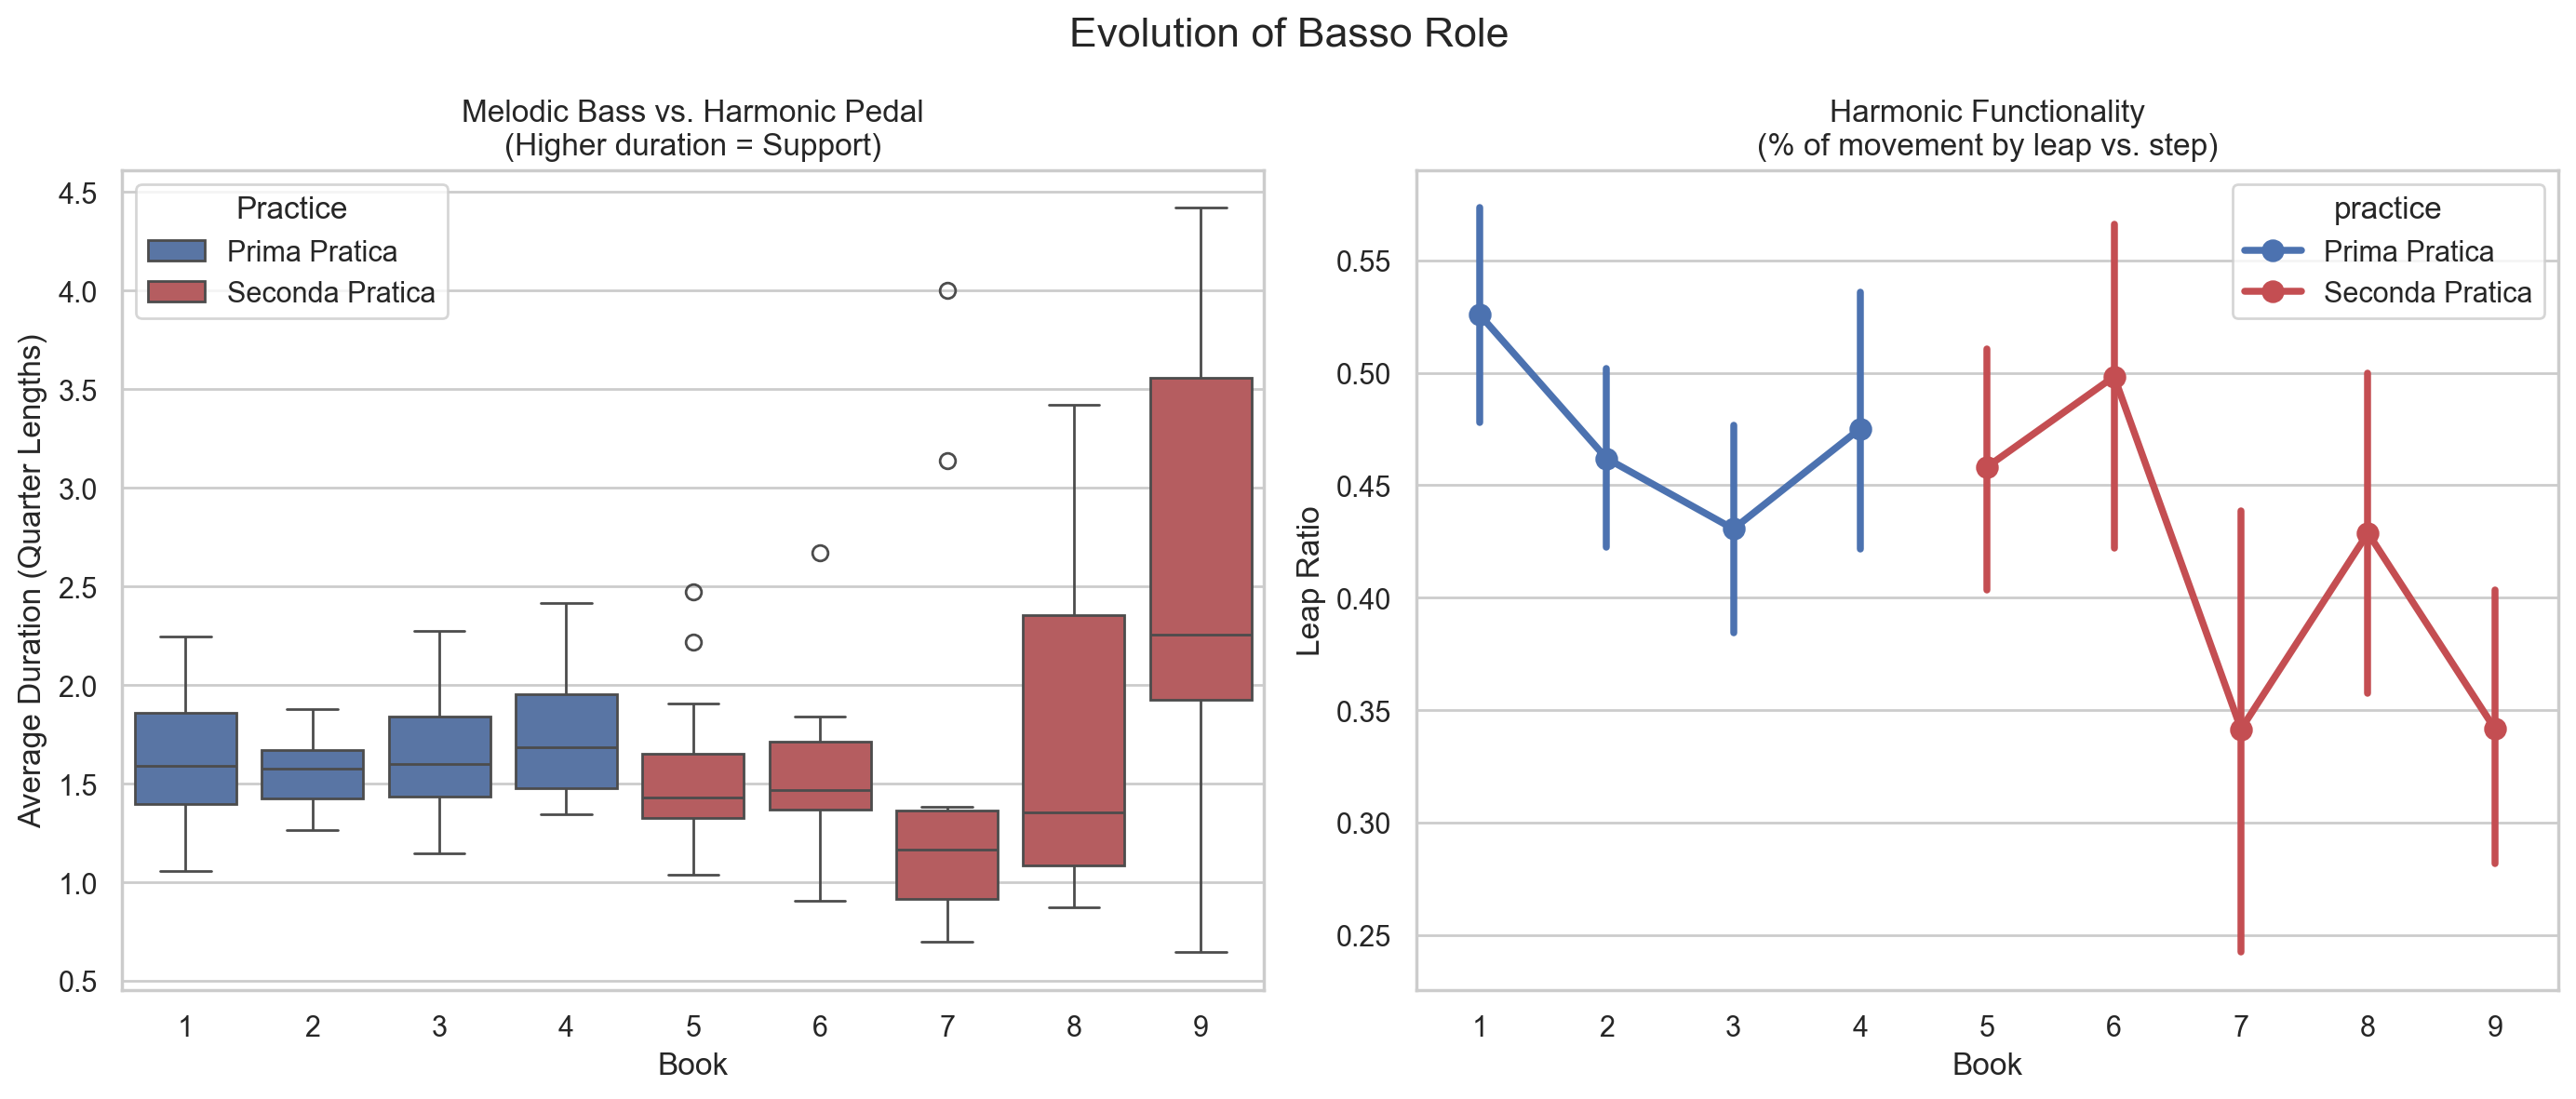

In [36]:
# ==========================================
# 1. Analytical Functions for Texture and Basso
# ==========================================
def analyze_texture_and_bass(score):
    """
    Analyzes vocal texture (homorhythm vs. polyphony) and the 
    melodic/harmonic behavior of the Basso Continuo.
    Returns None if the piece does NOT have Basso Continuo.
    """
    def is_basso_continuo(part):
        tags = [str(getattr(part, 'partName', '') or ''), str(getattr(part, 'id', '') or '')]
        text = ' '.join(tags).lower()
        
        # Search terms in lowercase
        search_terms = [
            '3  basso  a – b', "3  basso  a – c'  2", '3  basso  g – b', "3  basso  g – c'  1", "3  basso  g – d'", "3  basso i  e – d'", '3 basso', '3 basso 2', 'basso', "basso  b – d'", "basso  b – d'  3  2", "basso  d – d'", "basso  d – e'", "basso  e – c '", "basso  e – c'", "basso  e – d'", 'basso  f – a', 'basso  f – b', 'basso  f – g', "basso  f– c'", "basso  g – c'", "basso  g – d'", "basso a – e'", "basso b – e'", "basso d – d'", 'basso e – b', 'basso f – a', 'basso f – b', "basso f – c'", "basso f – d'", 'basso f– b', "basso f– b '", "basso f– d'", 'basso g – b', "basso g – c'", "basso g – d'", "basso ii  f – d'"
        ]
        return any(k in text for k in search_terms)

    # 1. Separate Bass and Vocal Parts
    basso_parts = [p for p in score.parts if is_basso_continuo(p)]
    if not basso_parts:
        return None # DISCARD pieces without Basso Continuo
        
    basso_part = basso_parts[0]
    vocal_parts = [p for p in score.parts if p is not basso_part]
    
    if not vocal_parts:
        return None

    # 2. Basso Continuo Analysis (Support vs. Melody)
    bass_notes = [n for n in basso_part.flatten().notes if isinstance(n, note.Note)]
    if not bass_notes:
        return None
        
    # a) Average duration (longer notes = harmonic support)
    avg_bass_duration = sum(n.quarterLength for n in bass_notes) / len(bass_notes)
    
    # b) Percentage of leaps (Leaps vs. Steps)
    steps = 0
    leaps = 0
    for i in range(1, len(bass_notes)):
        interval = abs(bass_notes[i].pitch.midi - bass_notes[i-1].pitch.midi)
        if interval > 0: # Ignore repeated notes (pedals)
            if interval <= 2:
                steps += 1
            else:
                leaps += 1

    leap_ratio = leaps / (steps + leaps) if (steps + leaps) > 0 else 0

    # 3. Vocal Texture Analysis (Homorhythm vs. Polyphony)
    unique_onsets = set()
    total_vocal_notes = 0
    
    for vp in vocal_parts:
        v_notes = [n for n in vp.flatten().notes if isinstance(n, note.Note)]
        for n in v_notes:
            total_vocal_notes += 1
            unique_onsets.add(float(n.offset))
            
    # Rhythmic Independence = Count of unique onsets / Total notes
    # Near 0 = Massed chords/Homorhythm. Near 1 = Total polyphony / Monody
    if total_vocal_notes > 0:
        rhythmic_independence = len(unique_onsets) / total_vocal_notes
    else:
        rhythmic_independence = np.nan

    return {
        'Avg_Bass_Duration': avg_bass_duration,
        'Bass_Leap_Ratio': leap_ratio,
        'Vocal_Rhythmic_Independence': rhythmic_independence
    }

# ==========================================
# 2. Dataset Processing
# ==========================================
def run_texture_analysis(data_root="data"):
    root = Path(data_root)
    mxl_files = [p for p in root.rglob("*") if p.is_file() and p.suffix.lower() in [".mxl", ".xml"]]
    
    rows = []
    
    print(f"Searching for pieces with Basso Continuo in {len(mxl_files)} files...")

    for fp in mxl_files:
        rel = str(fp.relative_to(root))
        m = re.search(r"Book_(\d+)", rel.replace("\\", "/"), flags=re.IGNORECASE)
        book_num = int(m.group(1)) if m else None
        
        if book_num is None or not (1 <= book_num <= 9):
            continue

        try:
            sc = converter.parse(str(fp))
            data = analyze_texture_and_bass(sc)
            
            if data is not None: # Only save if Basso Continuo was found
                row = {
                    "file_path": str(fp),
                    "book": book_num,
                    "practice": "Prima Pratica" if book_num <= 4 else "Seconda Pratica"
                }
                row.update(data)
                rows.append(row)
        except Exception:
            continue
            
    df = pd.DataFrame(rows)
    return df

# ==========================================
# 3. Visualization
# ==========================================
def visualize_texture_and_bass(df):
    if df.empty:
        print("No data found.")
        return

    sns.set_theme(style="whitegrid")
    # Reduced to 1 row and 2 columns
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle('Evolution of Basso Role', fontsize=16)

    colors = {'Prima Pratica': '#4C72B0', 'Seconda Pratica': '#C44E52'}

    # 1. Evolution of Harmonic Support (Bass Duration)
    sns.boxplot(data=df, x='book', y='Avg_Bass_Duration', hue='practice', palette=colors, ax=axes[0], dodge=False)
    axes[0].set_title('Melodic Bass vs. Harmonic Pedal\n(Higher duration = Support)')
    axes[0].set_ylabel('Average Duration (Quarter Lengths)')
    axes[0].set_xlabel('Book')
    axes[0].legend(title='Practice')

    # 2. Bass Functionality (Leaps)
    sns.pointplot(data=df, x='book', y='Bass_Leap_Ratio', hue='practice', palette=colors, ax=axes[1])
    axes[1].set_title('Harmonic Functionality\n(% of movement by leap vs. step)')
    axes[1].set_ylabel('Leap Ratio')
    axes[1].set_xlabel('Book')

    plt.tight_layout()
    plt.show()

# ==========================================
# 4. Execution
# ==========================================
df_texture = run_texture_analysis("data/choral_wiki_monteverdi_cleaned")
if not df_texture.empty:
    print(df_texture.head())
    visualize_texture_and_bass(df_texture)

Analyzing Stile Concitato across 184 files...


c:\UPF\Monteverdi_sprezzatura\Monteverdi-s-Sprezzatura-Analysis\.venv\Lib\site-packages\music21\musicxml\xmlToM21.py:1995: MusicXMLWarning: The following exception took place in m. 1 in part Basso da  Coro  gamba.
  warnings.warn(


                                           file_path  book       practice  \
0  data\choral_wiki_monteverdi_cleaned\Book_1\1-0...     1  Prima Pratica   
1  data\choral_wiki_monteverdi_cleaned\Book_1\1-0...     1  Prima Pratica   
2  data\choral_wiki_monteverdi_cleaned\Book_1\1-0...     1  Prima Pratica   
3  data\choral_wiki_monteverdi_cleaned\Book_1\1-0...     1  Prima Pratica   
4  data\choral_wiki_monteverdi_cleaned\Book_1\1-0...     1  Prima Pratica   

   Total_Notes  Concitato_Count  Concitato_Frequency_Pct  
0          556               11                 1.978417  
1          425                3                 0.705882  
2          480                0                 0.000000  
3          449                4                 0.890869  
4          734                7                 0.953678  


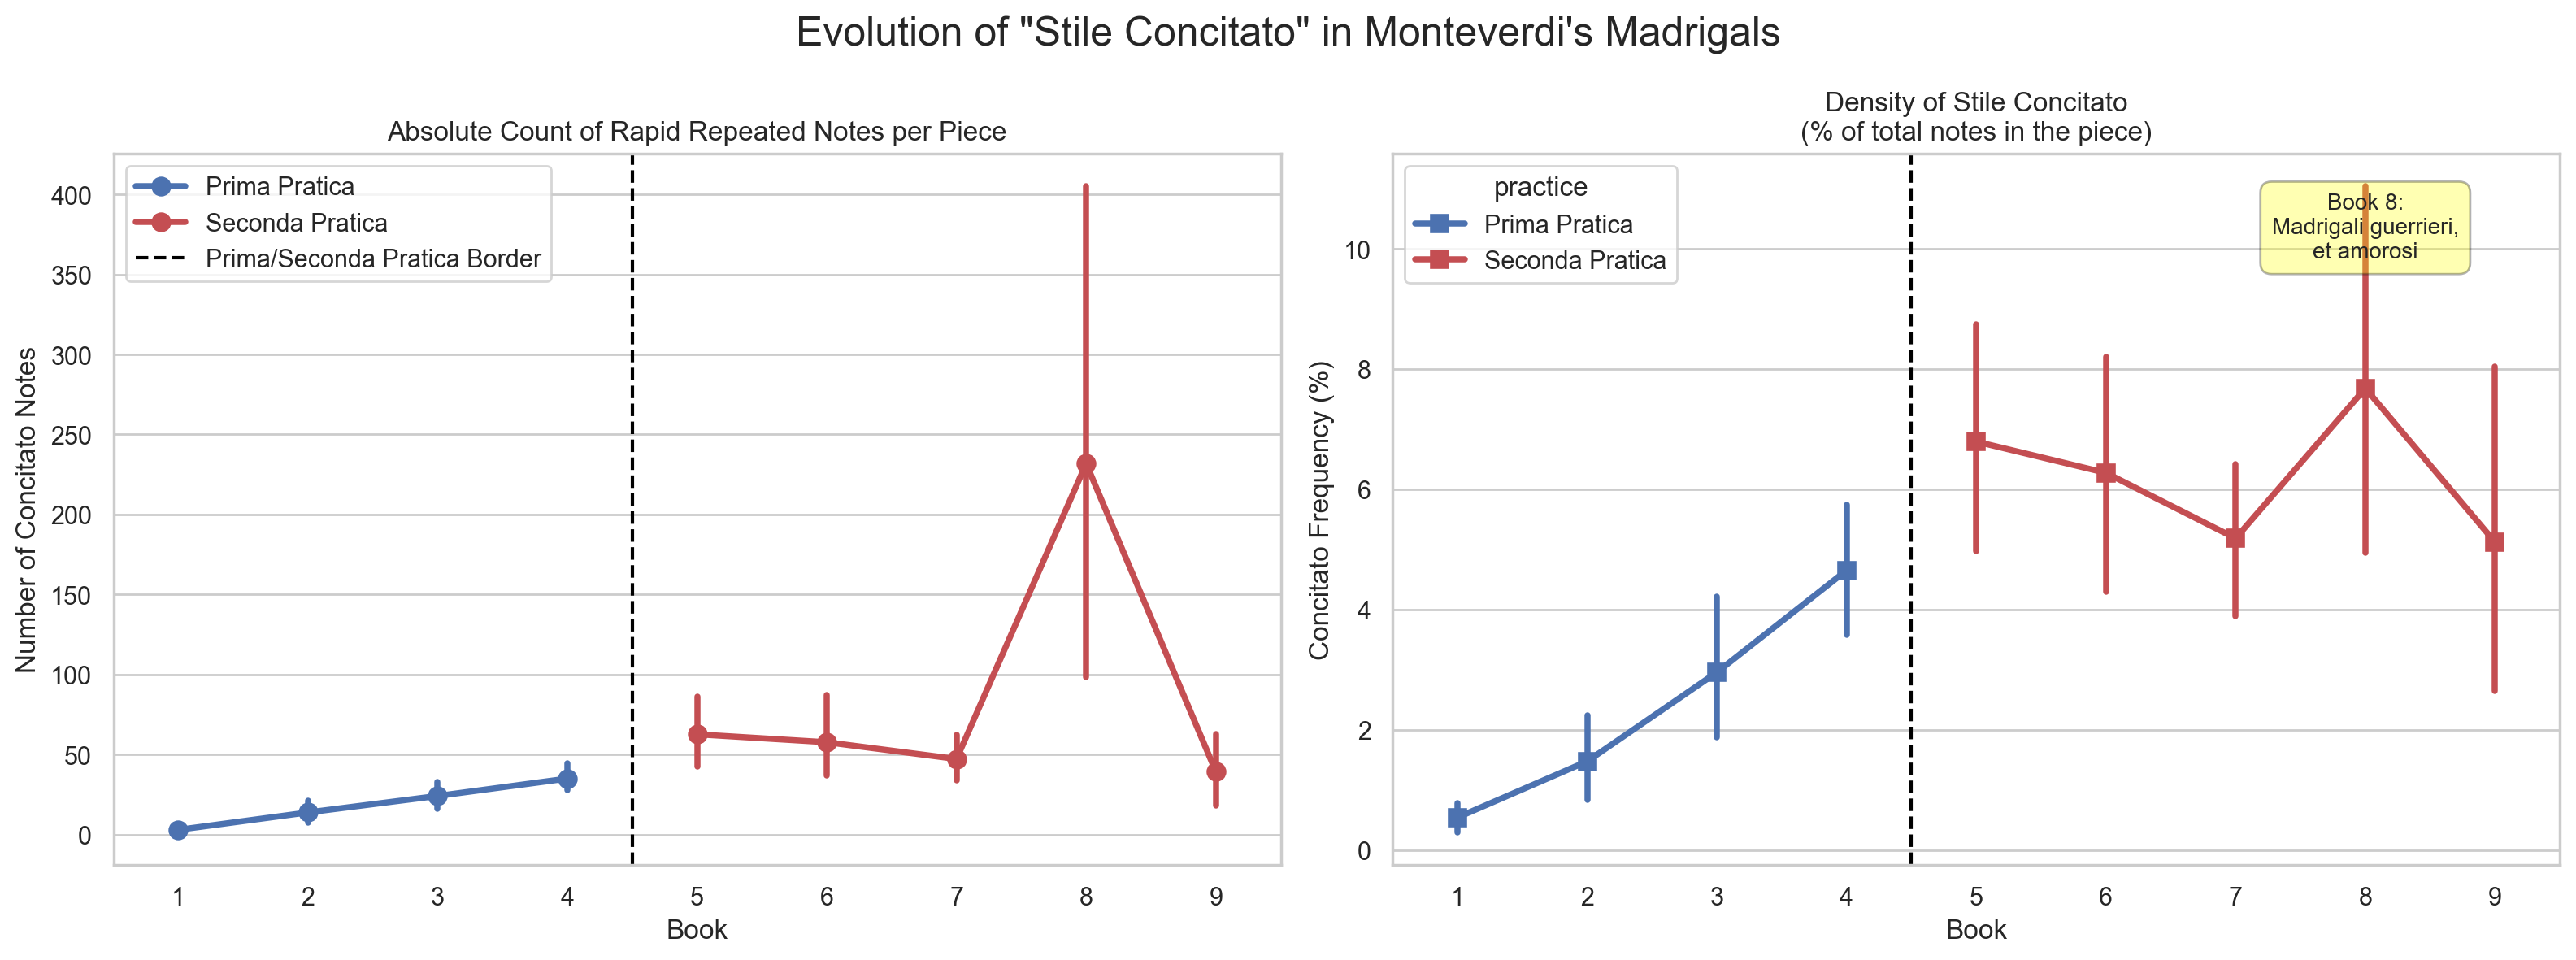

In [37]:
# ==========================================
# 1. Analytical Function: Stile Concitato
# ==========================================
def analyze_stile_concitato(score):
    """
    Detects 'Stile Concitato' by counting consecutive fast notes 
    (8th or 16th notes) played on the exact same pitch.
    """
    total_notes = 0
    concitato_notes = 0

    # Iterate through all parts (both voices and continuo)
    for part in score.parts:
        # Extract only individual notes (ignore chords and rests for this melodic check)
        notes = [n for n in part.flatten().notes if isinstance(n, note.Note)]
        total_notes += len(notes)
        
        if len(notes) < 2:
            continue
            
        # Iterate through notes to find fast repetitions
        for i in range(1, len(notes)):
            prev_n = notes[i-1]
            curr_n = notes[i]
            
            # Check if both notes are fast (quarterLength <= 0.5 means 8th note or shorter)
            if curr_n.quarterLength <= 0.5 and prev_n.quarterLength <= 0.5:
                # Check if they are on the exact same pitch
                if curr_n.pitch.midi == prev_n.pitch.midi:
                    concitato_notes += 1

    if total_notes == 0:
        return None

    return {
        'Total_Notes': total_notes,
        'Concitato_Count': concitato_notes,
        'Concitato_Frequency_Pct': (concitato_notes / total_notes) * 100
    }

# ==========================================
# 2. Dataset Processing
# ==========================================
def run_concitato_analysis(data_root="data"):
    root = Path(data_root)
    mxl_files = [p for p in root.rglob("*") if p.is_file() and p.suffix.lower() in [".mxl", ".xml"]]
    
    rows = []
    
    print(f"Analyzing Stile Concitato across {len(mxl_files)} files...")

    for fp in mxl_files:
        rel = str(fp.relative_to(root))
        m = re.search(r"Book_(\d+)", rel.replace("\\", "/"), flags=re.IGNORECASE)
        book_num = int(m.group(1)) if m else None
        
        if book_num is None or not (1 <= book_num <= 9):
            continue

        try:
            sc = converter.parse(str(fp))
            data = analyze_stile_concitato(sc)
            
            if data is not None:
                row = {
                    "file_path": str(fp),
                    "book": book_num,
                    "practice": "Prima Pratica" if book_num <= 4 else "Seconda Pratica"
                }
                row.update(data)
                rows.append(row)
        except Exception:
            continue
            
    df = pd.DataFrame(rows)
    return df

# ==========================================
# 3. Visualization
# ==========================================
def visualize_stile_concitato(df):
    if df.empty:
        print("No data found.")
        return

    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Evolution of "Stile Concitato" in Monteverdi\'s Madrigals', fontsize=18)

    colors = {'Prima Pratica': '#4C72B0', 'Seconda Pratica': '#C44E52'}

    # 1. Point Plot: Absolute Count of Concitato Notes
    sns.pointplot(data=df, x='book', y='Concitato_Count', hue='practice', palette=colors, ax=axes[0], markers="o", linestyles="-")
    axes[0].set_title('Absolute Count of Rapid Repeated Notes per Piece')
    axes[0].set_ylabel('Number of Concitato Notes')
    axes[0].set_xlabel('Book')
    axes[0].axvline(x=3.5, color='black', linestyle='--', linewidth=1.5, label='Prima/Seconda Pratica Border')
    axes[0].legend()

    # 2. Point Plot: Normalized Frequency (%)
    sns.pointplot(data=df, x='book', y='Concitato_Frequency_Pct', hue='practice', palette=colors, ax=axes[1], markers="s", linestyles="-")
    axes[1].set_title('Density of Stile Concitato\n(% of total notes in the piece)')
    axes[1].set_ylabel('Concitato Frequency (%)')
    axes[1].set_xlabel('Book')
    axes[1].axvline(x=3.5, color='black', linestyle='--', linewidth=1.5)

    # Adding historical context annotations (Monteverdi formally introduces it in Book 8)
    ymin, ymax = axes[1].get_ylim()
    axes[1].text(7.0, ymax * 0.85, 'Book 8:\nMadrigali guerrieri,\net amorosi', ha='center', fontsize=10, 
                 bbox=dict(facecolor='yellow', alpha=0.3, edgecolor='black', boxstyle='round,pad=0.5'))

    plt.tight_layout()
    plt.show()

# ==========================================
# 4. Execution 
# ==========================================
df_concitato = run_concitato_analysis("data/choral_wiki_monteverdi_cleaned")
if not df_concitato.empty:
    print(df_concitato.head())
    visualize_stile_concitato(df_concitato)

Scanning for dissonant words across 184 files...


c:\UPF\Monteverdi_sprezzatura\Monteverdi-s-Sprezzatura-Analysis\.venv\Lib\site-packages\music21\musicxml\xmlToM21.py:1995: MusicXMLWarning: The following exception took place in m. 1 in part Basso da  Coro  gamba.
  warnings.warn(


--- Top 10 Most Frequent Dissonant Words Overall ---


,Book,Word,Dissonance_Count
0,1,morire,140
1,1,vita,128
851,3,felice,106
852,3,questo,102
853,3,desio,98
2,1,dolce,84
854,3,dogni,81
855,3,come,74
3,1,tuttavia,72
4,1,vendettaamor,68


C:\Users\User\AppData\Local\Temp\ipykernel_20220\412666578.py:183: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\User\AppData\Local\Temp\ipykernel_20220\412666578.py:183: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\User\AppData\Local\Temp\ipykernel_20220\412666578.py:183: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\User\AppData\Local\Temp\ipykernel_20220\412666578.py:183: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` 

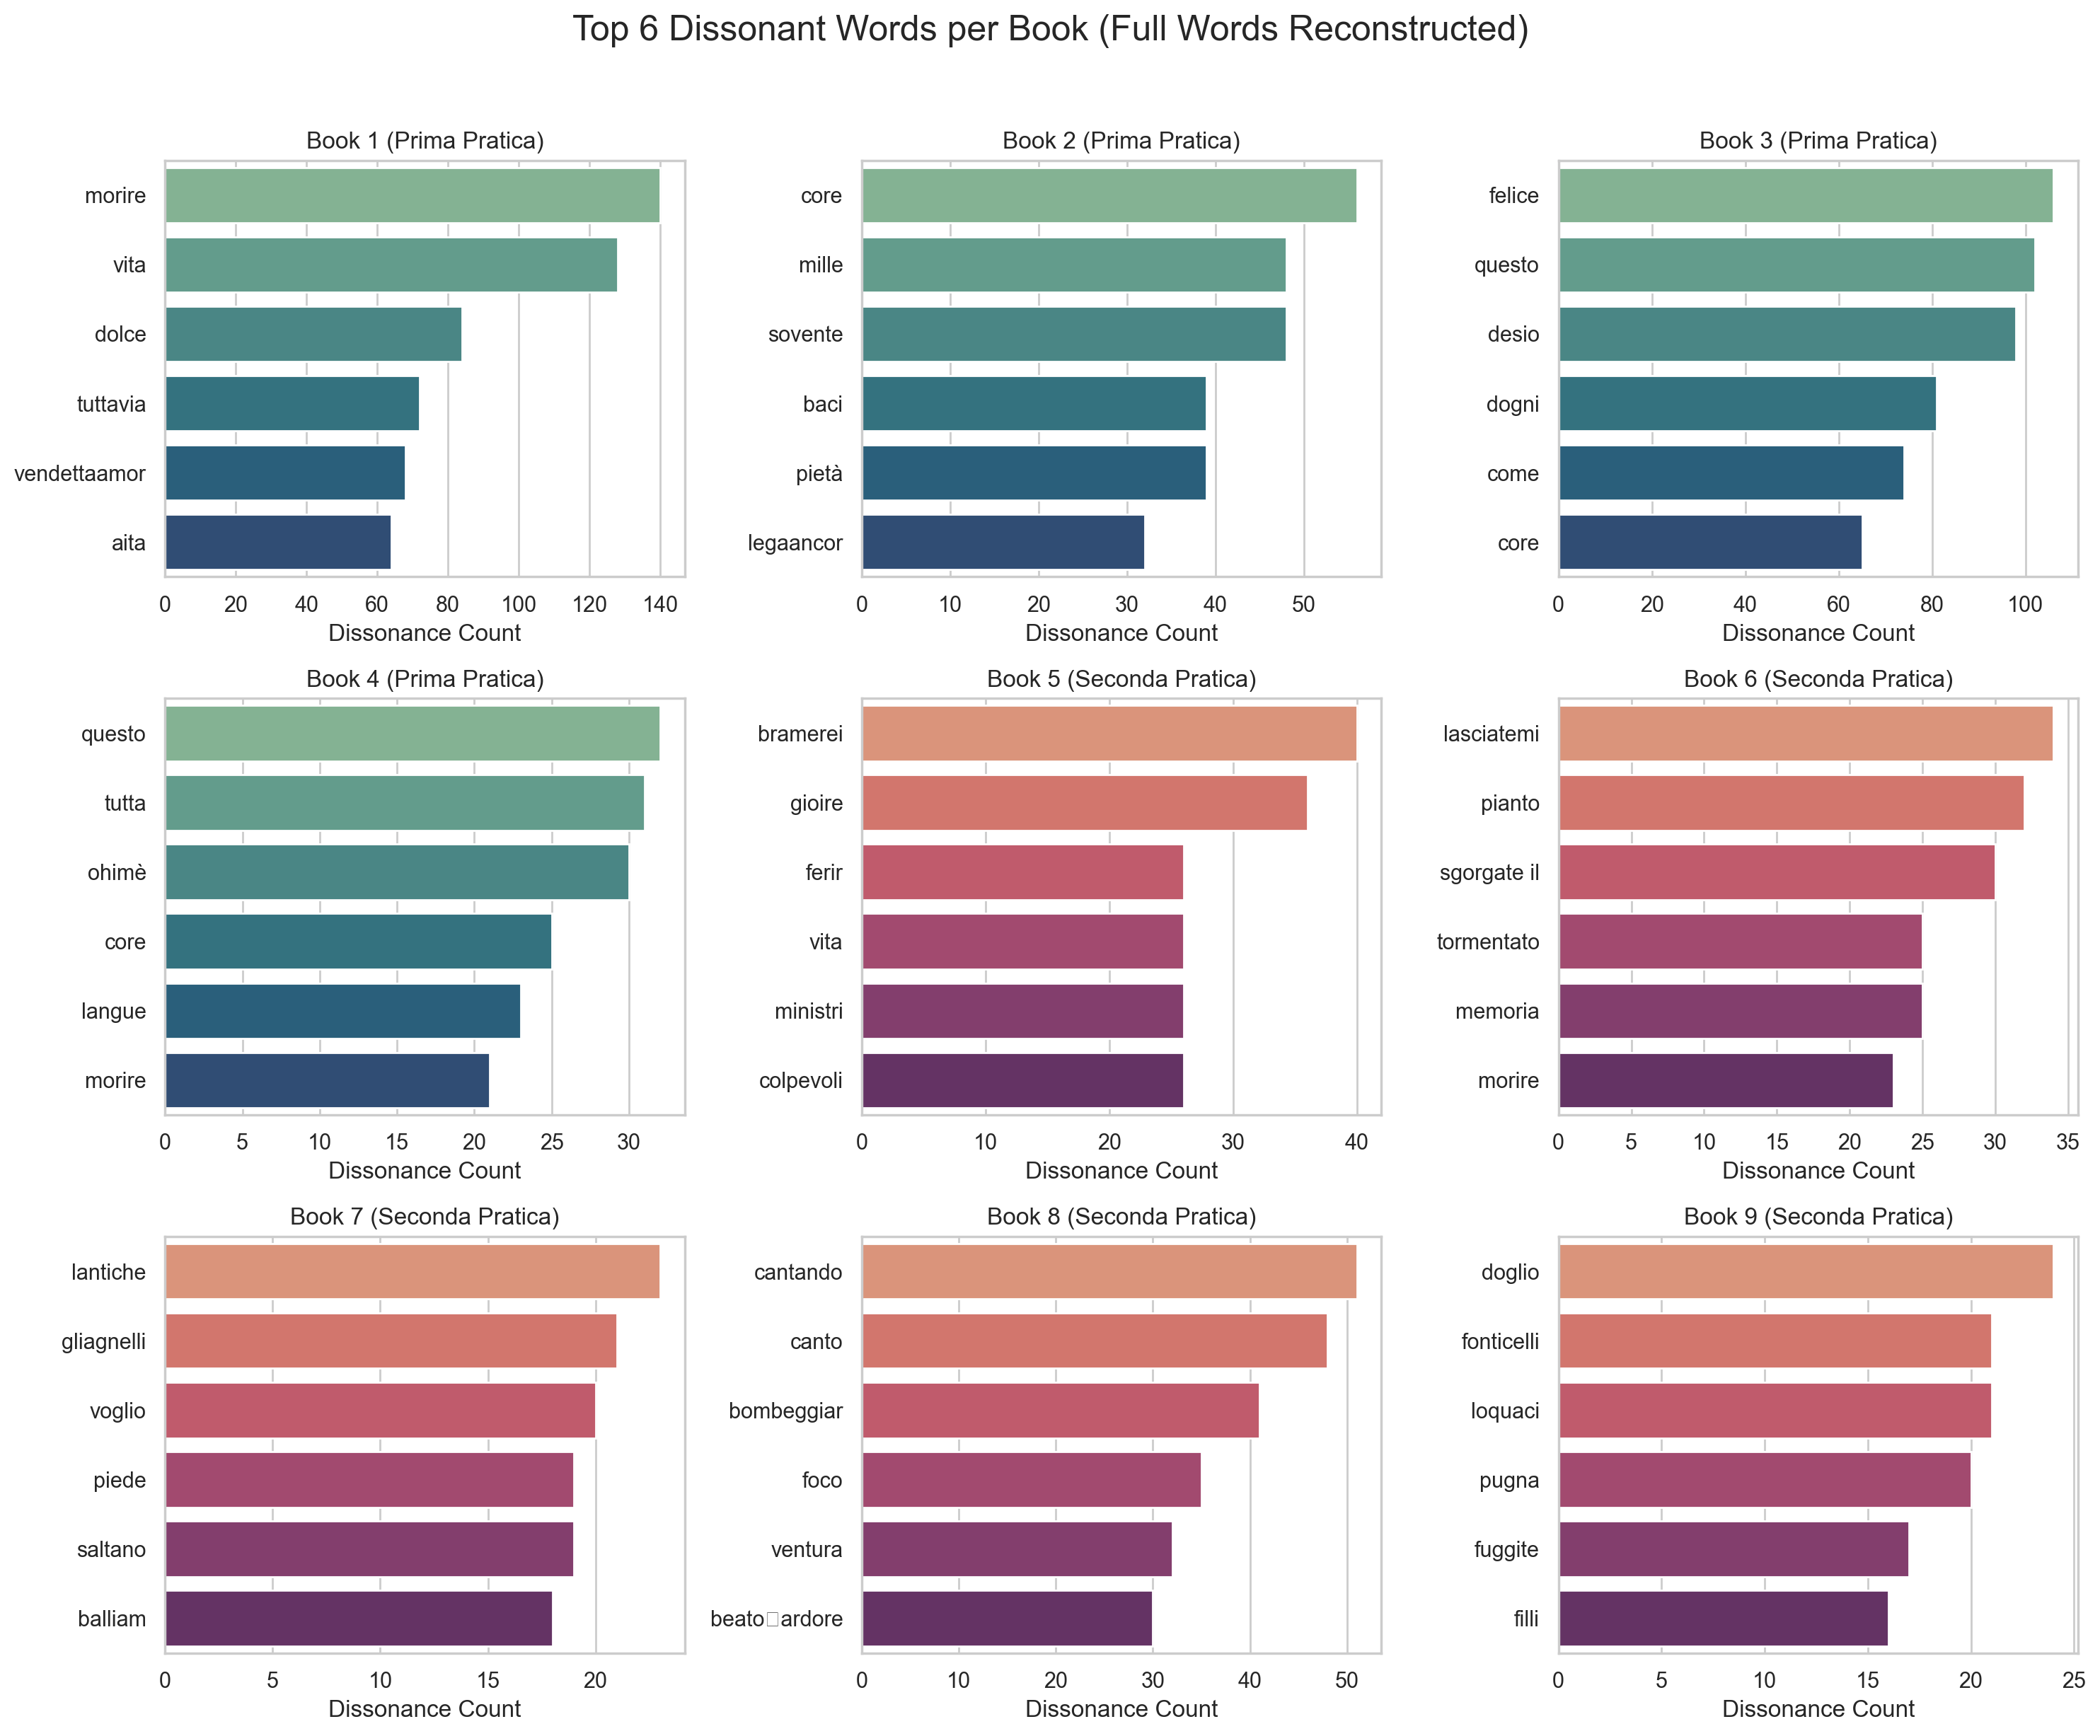

In [59]:
# ==========================================
# 1. Analytical Function: Dissonant Words
# ==========================================
def clean_full_word(word_str):
    """
    Cleans the reconstructed full word by removing hyphens, 
    underscores, punctuation, and converting to lowercase.
    """
    if not word_str:
        return None
    cleaned = str(word_str).replace('-', '').replace('_', '').strip().lower()
    cleaned = cleaned.translate(str.maketrans('', '', string.punctuation))
    return cleaned if cleaned else None

def build_note_to_word_map(part_flat):
    """
    Iterates through a part and reconstructs full words from syllables.
    Returns a dictionary mapping the Python object id(note) to its full word.
    """
    note_to_word = {}
    current_word_notes = []
    current_syllables = []
    
    for n in part_flat.notes:
        if not isinstance(n, note.Note) or not n.lyrics:
            continue
            
        ly = n.lyrics[0]
        syllabic = ly.syllabic  # Can be 'begin', 'middle', 'end', 'single', or None
        text = str(ly.text or "").replace('-', '').strip()
        
        if not text:
            continue
            
        if syllabic == 'single' or syllabic is None:
            # If there was a pending word that didn't close properly, save it
            if current_word_notes:
                full_word = "".join(current_syllables)
                for cn in current_word_notes:
                    note_to_word[id(cn)] = full_word
                current_word_notes = []
                current_syllables = []
                
            #note_to_word[id(n)] = text
            
        elif syllabic == 'begin':
            # Start a new multi-syllable word
            if current_word_notes:
                full_word = "".join(current_syllables)
                for cn in current_word_notes:
                    note_to_word[id(cn)] = full_word
                    
            current_word_notes = [n]
            current_syllables = [text]
            
        elif syllabic == 'middle':
            current_word_notes.append(n)
            current_syllables.append(text)
            
        elif syllabic == 'end':
            current_word_notes.append(n)
            current_syllables.append(text)
            
            # Finish the word and map it to all its constituent notes
            full_word = "".join(current_syllables)
            for cn in current_word_notes:
                note_to_word[id(cn)] = full_word
                
            current_word_notes = []
            current_syllables = []
            
    # Catch any trailing words at the end of the piece
    if current_word_notes:
        full_word = "".join(current_syllables)
        for cn in current_word_notes:
            note_to_word[id(cn)] = full_word
            
    return note_to_word

def analyze_dissonant_words(data_root="data"):
    """
    Scans all scores to find full words that occur on 
    dissonant vertical chords (3 or more notes).
    """
    root = Path(data_root)
    mxl_files = [p for p in root.rglob("*") if p.is_file() and p.suffix.lower() in [".mxl", ".xml"]]
    
    # Dictionary to store counts: {(Book, Word): Count}
    word_counts = {}
    
    print(f"Scanning for dissonant words across {len(mxl_files)} files...")

    for fp in mxl_files:
        rel = str(fp.relative_to(root))
        m = re.search(r"Book_(\d+)", rel.replace("\\", "/"), flags=re.IGNORECASE)
        book_num = int(m.group(1)) if m else None
        
        if book_num is None or not (1 <= book_num <= 9):
            continue

        try:
            sc = converter.parse(str(fp))
            parts_flat = [p.flatten() for p in sc.parts]
            
            # Map full words for each part
            part_word_maps = [build_note_to_word_map(p_flat) for p_flat in parts_flat]
            
            for i, p_flat in enumerate(parts_flat):
                note_word_map = part_word_maps[i]
                notes_with_lyrics = [n for n in p_flat.notes if isinstance(n, note.Note) and id(n) in note_word_map]
                
                for n in notes_with_lyrics:
                    t_onset = n.offset
                    
                    # Gather all pitches sounding at this exact moment
                    sounding_pitches = []
                    for other_p in parts_flat:
                        active_elements = other_p.getElementsByOffset(
                            t_onset, mustBeginInSpan=False, 
                            includeElementsThatEndAtStart=False, 
                            classList=['Note', 'Chord']
                        )
                        if active_elements:
                            elem = active_elements[0]
                            if isinstance(elem, note.Note):
                                sounding_pitches.append(elem.pitch)
                            elif isinstance(elem, chord.Chord):
                                sounding_pitches.extend(elem.pitches)
                                
                    # Filter unique pitch classes
                    unique_pitch_classes = set(p.pitchClass for p in sounding_pitches)
                    
                    # Metric: Check if stack has > 2 notes AND is dissonant
                    if len(unique_pitch_classes) > 2:
                        test_chord = chord.Chord(sounding_pitches)
                        if not test_chord.isConsonant():
                            # Retrieve the FULL WORD instead of just the syllable
                            raw_word = note_word_map[id(n)]
                            word = clean_full_word(raw_word)
                            
                            if word:
                                key = (book_num, word)
                                word_counts[key] = word_counts.get(key, 0) + 1
                                
        except Exception:
            continue
            
    rows = [{"Book": k[0], "Word": k[1], "Dissonance_Count": v} for k, v in word_counts.items()]
    df = pd.DataFrame(rows)
    
    if not df.empty:
        df = df.sort_values(by=["Book", "Dissonance_Count"], ascending=[True, False]).reset_index(drop=True)
        
    return df

# ==========================================
# 2. Visualization
# ==========================================
def visualize_dissonant_words(df):
    if df.empty:
        print("No dissonant words found.")
        return

    sns.set_theme(style="whitegrid")
    
    books = sorted(df['Book'].unique())
    num_books = len(books)
    
    cols = 3
    rows = int(np.ceil(num_books / cols))
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
    fig.suptitle("Top 6 Dissonant Words per Book (Full Words Reconstructed)", fontsize=18, y=1.02)
    
    axes = axes.flatten() if num_books > 1 else [axes]
    
    for i, book_num in enumerate(books):
        ax = axes[i]
        
        # Filter top 6 words for this book
        book_df = df[df['Book'] == book_num].head(6)
        
        sns.barplot(
            data=book_df, 
            x='Dissonance_Count', 
            y='Word', 
            ax=ax, 
            palette="flare" if book_num >= 5 else "crest",
            orient='h'
        )
        
        practice_label = "Prima Pratica" if book_num <= 4 else "Seconda Pratica"
        ax.set_title(f"Book {book_num} ({practice_label})")
        ax.set_xlabel("Dissonance Count")
        ax.set_ylabel("")
        
    for j in range(num_books, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

# ==========================================
# 3. Execution 
# ==========================================
df_words = analyze_dissonant_words("data/choral_wiki_monteverdi_cleaned")

if not df_words.empty:
    print("--- Top 10 Most Frequent Dissonant Words Overall ---")
    display(df_words.sort_values(by="Dissonance_Count", ascending=False).head(10))
    visualize_dissonant_words(df_words)

In [60]:
# Sprezzatura Heuristic Finder.
# ==========================================
# 1. Helper Functions 
# ==========================================
def clean_full_word(word_str):
    if not word_str: return None
    cleaned = str(word_str).replace('-', '').replace('_', '').strip().lower()
    return cleaned.translate(str.maketrans('', '', string.punctuation))

def build_note_to_word_map(part_flat):
    note_to_word = {}
    current_word_notes, current_syllables = [], []
    
    for n in part_flat.notes:
        if not isinstance(n, note.Note) or not n.lyrics: continue
        
        ly = n.lyrics[0]
        syllabic = ly.syllabic
        text = str(ly.text or "").replace('-', '').strip()
        if not text: continue
            
        if syllabic in ['single', None]:
            if current_word_notes:
                full_word = "".join(current_syllables)
                for cn in current_word_notes: note_to_word[id(cn)] = full_word
                current_word_notes, current_syllables = [], []
            note_to_word[id(n)] = text
            
        elif syllabic == 'begin':
            if current_word_notes:
                full_word = "".join(current_syllables)
                for cn in current_word_notes: note_to_word[id(cn)] = full_word
            current_word_notes, current_syllables = [n], [text]
            
        elif syllabic == 'middle':
            current_word_notes.append(n)
            current_syllables.append(text)
            
        elif syllabic == 'end':
            current_word_notes.append(n)
            current_syllables.append(text)
            full_word = "".join(current_syllables)
            for cn in current_word_notes: note_to_word[id(cn)] = full_word
            current_word_notes, current_syllables = [], []
            
    if current_word_notes:
        full_word = "".join(current_syllables)
        for cn in current_word_notes: note_to_word[id(cn)] = full_word
            
    return note_to_word

# ==========================================
# 2. Main Sprezzatura Finder (Capped Scoring)
# ==========================================
def find_all_sprezzatura(score_path):
    print(f"Loading Score: {score_path}...")
    try:
        sc = converter.parse(score_path)
    except Exception as e:
        print(f"Error loading score: {e}")
        return None

    parts_flat = [p.flatten() for p in sc.parts]
    part_word_maps = [build_note_to_word_map(p_flat) for p_flat in parts_flat]
    
    bass_part = sc.parts[-1]
    for p in sc.parts:
        if any(name in str(p.partName).lower() for name in ['basso', 'bc', 'continuo']):
            bass_part = p
            break
            
    bass_flat = bass_part.flatten()

    measure_scores = {}
    measure_details = {} 

    measures = sc.parts[0].getElementsByClass(stream.Measure)
    
    for m in measures:
        m_num = m.number
        if m_num == 0: continue
        
        score_for_measure = 0
        details = []
        
        # 1. BASS SUPPORT (Max 2 points per measure)
        has_bass_pedal = False
        bass_measure = bass_flat.getElementsByOffset(m.offset, m.offset + m.quarterLength, includeElementsThatEndAtStart=False)
        bass_notes = [n for n in bass_measure.notes if isinstance(n, note.Note)]
        for bn in bass_notes:
            if bn.quarterLength >= 2.0: 
                has_bass_pedal = True
                break
                
        if has_bass_pedal:
            score_for_measure += 2
            details.append("Bass Pedal/Support")

        # 2. STILE CONCITATO / REPEATED DECLAMATION (Max 3 points per measure)
        has_declamation = False
        for p_flat in parts_flat:
            if has_declamation: break
            p_measure = p_flat.getElementsByOffset(m.offset, m.offset + m.quarterLength, includeElementsThatEndAtStart=False)
            v_notes = [n for n in p_measure.notes if isinstance(n, note.Note)]
            for i in range(1, len(v_notes)):
                if v_notes[i].pitch == v_notes[i-1].pitch and v_notes[i].quarterLength <= 1.0:
                    has_declamation = True
                    break
                    
        if has_declamation:
            score_for_measure += 3 
            details.append("Repeated Notes (Declamation)")

        # 3. DISSONANT WORDS (Max 5 points per measure)
        has_dissonance = False
        dissonant_words_in_measure = set()
        
        for i, p_flat in enumerate(parts_flat):
            note_word_map = part_word_maps[i]
            p_measure = p_flat.getElementsByOffset(m.offset, m.offset + m.quarterLength, includeElementsThatEndAtStart=False)
            notes_with_lyrics = [n for n in p_measure.notes if isinstance(n, note.Note) and id(n) in note_word_map]
            
            for n in notes_with_lyrics:
                sounding_pitches = []
                for other_p in parts_flat:
                    active = other_p.getElementsByOffset(n.offset, mustBeginInSpan=False, includeElementsThatEndAtStart=False, classList=['Note', 'Chord'])
                    if active:
                        elem = active[0]
                        if isinstance(elem, note.Note): sounding_pitches.append(elem.pitch)
                        elif isinstance(elem, chord.Chord): sounding_pitches.extend(elem.pitches)
                        
                unique_pitch_classes = set(p.pitchClass for p in sounding_pitches)
                if len(unique_pitch_classes) > 2:
                    test_chord = chord.Chord(sounding_pitches)
                    if not test_chord.isConsonant():
                        has_dissonance = True
                        word = clean_full_word(note_word_map[id(n)])
                        if word: dissonant_words_in_measure.add(word)
                        
        if has_dissonance:
            score_for_measure += 5 
            words_str = ", ".join(dissonant_words_in_measure)
            details.append(f'Dissonance on "{words_str}"')
        
        # Save the score if it triggered any of our metrics
        if score_for_measure > 0:
            measure_scores[m_num] = score_for_measure
            measure_details[m_num] = " | ".join(details)

    # Convert to DataFrame
    if not measure_scores:
        print("No Sprezzatura moments found in this piece.")
        return pd.DataFrame()
        
    df_results = pd.DataFrame([
        {"Measure": m, "Score": s, "Features": measure_details[m]} 
        for m, s in measure_scores.items()
    ])
    
    # Sort by Score descending, then by Measure ascending
    df_results = df_results.sort_values(by=["Score", "Measure"], ascending=[False, True]).reset_index(drop=True)

    print("\n" + "="*50)
    print(f"PROBABLE MEASURES WITH SPREZZATURA AND ITS FEATURES:")
    print("="*50)
    
    # Display the top ones in the console
    print(df_results.head(15).to_string(index=False))
    print("-" * 50)

    # Extract snippets for measures that scored a perfect 10 (or the top 3, whichever is greater)
    top_scorers = df_results[df_results['Score'] == df_results['Score'].max()]
    top_n_to_extract = max(3, len(top_scorers))
    
    print(f"\nExtracting context (2 measures before & after) for the Top {top_n_to_extract} Hotspots...")
    
    for i in range(min(top_n_to_extract, len(df_results))):
        target_m = df_results.loc[i, "Measure"]
        
    return df_results

# ==========================================
# 3. Execution
# ==========================================
#score_path = r"Path/to/your/score"
score_path = r"data\choral_wiki_monteverdi_cleaned\Book_5\5-01-Cruda Amarilli\Monte-5-01.mxl"
df_sprezzatura = find_all_sprezzatura(score_path)

Loading Score: data\choral_wiki_monteverdi_cleaned\Book_5\5-01-Cruda Amarilli\Monte-5-01.mxl...

PROBABLE MEASURES WITH SPREZZATURA AND ITS FEATURES:
 Measure  Score                                                                                                               Features
       2     10                                           Bass Pedal/Support | Repeated Notes (Declamation) | Dissonance on "crurilli"
       8     10                                                Bass Pedal/Support | Repeated Notes (Declamation) | Dissonance on "col"
       9     10                  Bass Pedal/Support | Repeated Notes (Declamation) | Dissonance on "damar, co, col, cora, da, ra, mar"
      10     10                  Bass Pedal/Support | Repeated Notes (Declamation) | Dissonance on "co, damar, cora, da, ra, ahi, mar"
      13     10                       Bass Pedal/Support | Repeated Notes (Declamation) | Dissonance on "col, las, ra, nome, ahi, che"
      14     10                         

In [58]:
print(df_sprezzatura)

    Measure  Score                                           Features
0         2     10  Bass Pedal/Support | Repeated Notes (Declamati...
1         8     10  Bass Pedal/Support | Repeated Notes (Declamati...
2         9     10  Bass Pedal/Support | Repeated Notes (Declamati...
3        10     10  Bass Pedal/Support | Repeated Notes (Declamati...
4        13     10  Bass Pedal/Support | Repeated Notes (Declamati...
5        14     10  Bass Pedal/Support | Repeated Notes (Declamati...
6        21     10  Bass Pedal/Support | Repeated Notes (Declamati...
7        33     10  Bass Pedal/Support | Repeated Notes (Declamati...
8        34     10  Bass Pedal/Support | Repeated Notes (Declamati...
9        37     10  Bass Pedal/Support | Repeated Notes (Declamati...
10       38     10  Bass Pedal/Support | Repeated Notes (Declamati...
11       39     10  Bass Pedal/Support | Repeated Notes (Declamati...
12       40     10  Bass Pedal/Support | Repeated Notes (Declamati...
13       46     10  